In [1]:
#importing libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as imb_pipe
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from time import time
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.tree import plot_tree


import warnings
warnings.filterwarnings('ignore')

from sklearn import set_config
set_config(transform_output='pandas')

from datetime import datetime

In [2]:
#Loading the data
client_data_train = pd.read_csv('data/train/client_train.csv')
invoice_data_train = pd.read_csv('data/train/invoice_train.csv')

In [3]:
client_data_train

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0
...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0
135489,63,train_Client_99996,11,311,25/10/2012,0.0
135490,63,train_Client_99997,11,311,22/11/2011,0.0
135491,60,train_Client_99998,11,101,22/12/1993,0.0


In [4]:
invoice_data_train

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,2005-08-19,10,1253571,0,202,9,1,400,135,0,0,3197,3732,8,ELEC
4476745,train_Client_99998,2005-12-19,10,1253571,0,202,6,1,200,6,0,0,3732,3938,4,ELEC
4476746,train_Client_99999,1996-09-25,11,560948,0,203,6,1,259,0,0,0,13884,14143,4,ELEC
4476747,train_Client_99999,1996-05-28,11,560948,0,203,6,1,603,0,0,0,13281,13884,4,ELEC


In [5]:
client_data_train.shape

(135493, 6)

In [6]:
invoice_data_train.shape

(4476749, 16)

From the shape of these two data it is visible that there is a difference in shape. If we can recall the goal of the company is to detect which clients are involved in fraudulant activities and not to catch which bills are fraudulant. It can be asumed that there are clients who have multiple bills, which leads to the difference in shape. let us test the hypothesis

In [7]:
bill_counts = invoice_data_train.groupby('client_id').size().reset_index(name='Bill_Count')

# Display the result
bill_counts

,client_id,Bill_Count
0,train_Client_0,35
1,train_Client_1,37
2,train_Client_10,18
3,train_Client_100,20
4,train_Client_1000,14
...,...,...
135488,train_Client_99995,71
135489,train_Client_99996,41
135490,train_Client_99997,36
135491,train_Client_99998,2


In [8]:
bill_counts.isnull().sum()

client_id     0
Bill_Count    0
dtype: int64

In [9]:
client_data_train = client_data_train.merge(bill_counts, on='client_id', how='left')

client_data_train


,disrict,client_id,client_catg,region,creation_date,target,Bill_Count
0,60,train_Client_0,11,101,31/12/1994,0.0,35
1,69,train_Client_1,11,107,29/05/2002,0.0,37
2,62,train_Client_10,11,301,13/03/1986,0.0,18
3,69,train_Client_100,11,105,11/07/1996,0.0,20
4,62,train_Client_1000,11,303,14/10/2014,0.0,14
...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2


In [10]:
bill_counts.min()

client_id     train_Client_0
Bill_Count                 1
dtype: object

In [11]:
bill_counts.max()

client_id     train_Client_99999
Bill_Count                   439
dtype: object

In [12]:
client_data_train.head()

,disrict,client_id,client_catg,region,creation_date,target,Bill_Count
0,60,train_Client_0,11,101,31/12/1994,0.0,35
1,69,train_Client_1,11,107,29/05/2002,0.0,37
2,62,train_Client_10,11,301,13/03/1986,0.0,18
3,69,train_Client_100,11,105,11/07/1996,0.0,20
4,62,train_Client_1000,11,303,14/10/2014,0.0,14


In [13]:
invoice_data_train.head()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


In [14]:
client_data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
 6   Bill_Count     135493 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 7.2+ MB


In [15]:
invoice_data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          object
dtypes: int64(12), object(4)
memory usage: 546.5+ MB


In [16]:
client_data_train.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
Bill_Count       0
dtype: int64

In [17]:
invoice_data_train.isnull().sum()

client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [18]:
client_data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
disrict,135493.0,63.511222,3.354400,60.0,62.0,62.0,69.0,69.0
client_catg,135493.0,11.512506,4.423761,11.0,11.0,11.0,11.0,51.0
region,135493.0,206.159809,104.207044,101.0,103.0,107.0,307.0,399.0
target,135493.0,0.055841,0.229614,0.0,0.0,0.0,0.0,1.0
Bill_Count,135493.0,33.040445,26.092229,1.0,10.0,30.0,50.0,439.0


In [19]:
invoice_data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
tarif_type,4476749.0,2.012804e+01,1.347256e+01,8.0,11.0,11.0,40.0,4.500000e+01
counter_number,4476749.0,1.230587e+11,1.657267e+12,0.0,121108.0,494561.0,1115161.0,2.798115e+13
counter_code,4476749.0,1.724884e+02,1.338871e+02,0.0,5.0,203.0,207.0,6.000000e+02
reading_remarque,4476749.0,7.321702e+00,1.571654e+00,5.0,6.0,8.0,9.0,4.130000e+02
counter_coefficient,4476749.0,1.003040e+00,3.083466e-01,0.0,1.0,1.0,1.0,5.000000e+01
consommation_level_1,4476749.0,4.109795e+02,7.573080e+02,0.0,79.0,274.0,600.0,9.999100e+05
consommation_level_2,4476749.0,1.093225e+02,1.220123e+03,0.0,0.0,0.0,0.0,9.990730e+05
consommation_level_3,4476749.0,2.030620e+01,1.574239e+02,0.0,0.0,0.0,0.0,6.449200e+04
consommation_level_4,4476749.0,5.292588e+01,8.754725e+02,0.0,0.0,0.0,0.0,5.479460e+05
old_index,4476749.0,1.776700e+04,4.036693e+04,0.0,1791.0,7690.0,21660.0,2.800280e+06


In [20]:
invoice_data_train.duplicated().sum()

11

In [21]:
#Removing dulpicates because they can mess up the aggregation
invoice_data_train = invoice_data_train.drop_duplicates()

In [22]:
#Check if it worked
invoice_data_train.shape

(4476738, 16)

We have sucesfuly managed to remove the duplicates

Earlier in the client data we saw that there is a column called creation_date. now dates while they can be helpful for the model. For this reason we create some new features where we split the day month and year to seperate columns so that we can feed this data into our model

In [23]:
client_data_train['creation_day']=client_data_train['creation_date'].apply(lambda x:int(x.split('/')[0]))
client_data_train['creation_month']=client_data_train['creation_date'].apply(lambda x:int(x.split('/')[1]))
client_data_train['creation_year']=client_data_train['creation_date'].apply(lambda x:int(x.split('/')[2]))
client_data_train

,disrict,client_id,client_catg,region,creation_date,target,Bill_Count,creation_day,creation_month,creation_year
0,60,train_Client_0,11,101,31/12/1994,0.0,35,31,12,1994
1,69,train_Client_1,11,107,29/05/2002,0.0,37,29,5,2002
2,62,train_Client_10,11,301,13/03/1986,0.0,18,13,3,1986
3,69,train_Client_100,11,105,11/07/1996,0.0,20,11,7,1996
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,14,10,2014
...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,26,7,2004
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,25,10,2012
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,22,11,2011
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,22,12,1993


Let us take create a new feature in the invoice table. We take new_index and old_index and creeate a new feature called diff_index

In [24]:
invoice_data_train['diff_index']=invoice_data_train['new_index']-invoice_data_train['old_index']
invoice_data_train

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type,diff_index
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC,82
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC,1384
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC,123
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC,102
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC,572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,2005-08-19,10,1253571,0,202,9,1,400,135,0,0,3197,3732,8,ELEC,535
4476745,train_Client_99998,2005-12-19,10,1253571,0,202,6,1,200,6,0,0,3732,3938,4,ELEC,206
4476746,train_Client_99999,1996-09-25,11,560948,0,203,6,1,259,0,0,0,13884,14143,4,ELEC,259
4476747,train_Client_99999,1996-05-28,11,560948,0,203,6,1,603,0,0,0,13281,13884,4,ELEC,603


In [26]:
# Convert Invoice_date to datetime if not already
invoice_data_train['invoice_date'] = pd.to_datetime(invoice_data_train['invoice_date'])

# Sort by Client_id and Invoice_date
invoice_data_train = invoice_data_train.sort_values(by=['client_id', 'invoice_date'])

# Calculate the time difference between consecutive bills for each client
invoice_data_train['time_diff'] = invoice_data_train.groupby('client_id')['invoice_date'].diff().dt.days

# Compute the average frequency of bills (mean of Time_Diff) for each client
frequency_of_bills = (
    invoice_data_train.groupby('client_id')['time_diff']
    .mean()
    .reset_index(name='avg_frequency_of_bills_in_days')
)

# Display the result
frequency_of_bills.head()

,client_id,avg_frequency_of_bills_in_days
0,train_Client_0,144.147059
1,train_Client_1,136.472222
2,train_Client_10,289.470588
3,train_Client_100,140.210526
4,train_Client_1000,121.923077


In [27]:
client_data_train = client_data_train.merge(frequency_of_bills, on='client_id', how='left')


In [28]:
client_data_train

,disrict,client_id,client_catg,region,creation_date,target,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days
0,60,train_Client_0,11,101,31/12/1994,0.0,35,31,12,1994,144.147059
1,69,train_Client_1,11,107,29/05/2002,0.0,37,29,5,2002,136.472222
2,62,train_Client_10,11,301,13/03/1986,0.0,18,13,3,1986,289.470588
3,69,train_Client_100,11,105,11/07/1996,0.0,20,11,7,1996,140.210526
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,14,10,2014,121.923077
...,...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,26,7,2004,72.842857
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,25,10,2012,57.675000
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,22,11,2011,80.600000
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,22,12,1993,122.000000


In [29]:
client_data_train.isnull().sum()

disrict                              0
client_id                            0
client_catg                          0
region                               0
creation_date                        0
target                               0
Bill_Count                           0
creation_day                         0
creation_month                       0
creation_year                        0
avg_frequency_of_bills_in_days    4212
dtype: int64

In [30]:
drop_columns = ['invoice_date', 'counter_number', 'counter_statue', 'old_index', 'new_index', 'months_number', 'counter_code', 'time_diff']

In [31]:
invoice_data_train.drop(drop_columns,axis=1,inplace=True)
invoice_data_train

,client_id,tarif_type,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,counter_type,diff_index
22,train_Client_0,11,6,1,124,0,0,0,ELEC,124
23,train_Client_0,11,6,1,141,0,0,0,ELEC,141
24,train_Client_0,11,6,1,162,0,0,0,ELEC,162
25,train_Client_0,11,6,1,159,0,0,0,ELEC,159
28,train_Client_0,11,6,1,182,0,0,0,ELEC,182
...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,10,9,1,400,135,0,0,ELEC,535
4476745,train_Client_99998,10,6,1,200,6,0,0,ELEC,206
4476748,train_Client_99999,11,6,1,516,0,0,0,ELEC,516
4476747,train_Client_99999,11,6,1,603,0,0,0,ELEC,603


In [32]:
# Add a flag for single-bill clients
client_data_train['single_bill_client'] = client_data_train['avg_frequency_of_bills_in_days'].isnull().astype(int)


In [33]:
client_data_train.head(50)

,disrict,client_id,client_catg,region,creation_date,target,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client
0,60,train_Client_0,11,101,31/12/1994,0.0,35,31,12,1994,144.147059,0
1,69,train_Client_1,11,107,29/05/2002,0.0,37,29,5,2002,136.472222,0
2,62,train_Client_10,11,301,13/03/1986,0.0,18,13,3,1986,289.470588,0
3,69,train_Client_100,11,105,11/07/1996,0.0,20,11,7,1996,140.210526,0
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,14,10,2014,121.923077,0
5,69,train_Client_10000,11,103,29/09/1993,0.0,48,29,9,1993,98.425532,0
6,62,train_Client_100000,11,309,07/06/2012,0.0,40,7,6,2012,62.282051,0
7,60,train_Client_100001,11,101,12/04/2006,0.0,78,12,4,2006,64.532468,0
8,62,train_Client_100002,11,301,31/12/2006,0.0,2,31,12,2006,120.000000,0
9,60,train_Client_100003,11,101,25/10/2011,0.0,5,25,10,2011,223.750000,0


In [34]:
# Fill missing values in Frequency_of_Bills
median_frequency = client_data_train['avg_frequency_of_bills_in_days'].median()
client_data_train['avg_frequency_of_bills_in_days'].fillna(median_frequency, inplace=True)
client_data_train.head(50)


,disrict,client_id,client_catg,region,creation_date,target,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client
0,60,train_Client_0,11,101,31/12/1994,0.0,35,31,12,1994,144.147059,0
1,69,train_Client_1,11,107,29/05/2002,0.0,37,29,5,2002,136.472222,0
2,62,train_Client_10,11,301,13/03/1986,0.0,18,13,3,1986,289.470588,0
3,69,train_Client_100,11,105,11/07/1996,0.0,20,11,7,1996,140.210526,0
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,14,10,2014,121.923077,0
5,69,train_Client_10000,11,103,29/09/1993,0.0,48,29,9,1993,98.425532,0
6,62,train_Client_100000,11,309,07/06/2012,0.0,40,7,6,2012,62.282051,0
7,60,train_Client_100001,11,101,12/04/2006,0.0,78,12,4,2006,64.532468,0
8,62,train_Client_100002,11,301,31/12/2006,0.0,2,31,12,2006,120.000000,0
9,60,train_Client_100003,11,101,25/10/2011,0.0,5,25,10,2011,223.750000,0


In [35]:
# Group by client_id and aggregate
aggregated_invoice_data_train = invoice_data_train.groupby('client_id').agg({
    'tarif_type': lambda x: x.mode()[0],  # Mode
    'counter_coefficient': lambda x: x.mode()[0],  # Mode
    'counter_type': lambda x: x.mode()[0],  # Mode
    'reading_remarque': ['min', lambda x: x.mode()[0]],  # Min and Mode
    'consommation_level_1': ['mean', 'std'],  # Mean and Std Dev
    'consommation_level_2': ['mean', 'std'],  # Mean and Std Dev
    'consommation_level_3': ['mean', 'std'],  # Mean and Std Dev
    'consommation_level_4': ['mean', 'std'],  # Mean and Std Dev
    'diff_index': ['mean', 'std']  # Mean and Std Dev
}).reset_index()

# Flatten MultiIndex columns
aggregated_invoice_data_train.columns = ['_'.join(col).strip('_') for col in aggregated_invoice_data_train.columns]

aggregated_invoice_data_train

,client_id,tarif_type_<lambda>,counter_coefficient_<lambda>,counter_type_<lambda>,reading_remarque_min,reading_remarque_<lambda_0>,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_mean,consommation_level_4_std,diff_index_mean,diff_index_std
0,train_Client_0,11,1,ELEC,6,6,352.400000,310.343472,10.571429,43.568935,0.000000,0.000000,0.000000,0.000000,362.971429,341.553930
1,train_Client_1,11,1,ELEC,6,6,557.540541,197.935960,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,557.540541,197.935960
2,train_Client_10,11,1,ELEC,6,6,798.611111,513.841374,37.888889,160.748942,0.000000,0.000000,0.000000,0.000000,836.500000,646.808386
3,train_Client_100,11,1,ELEC,6,6,1.200000,3.607011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.200000,3.607011
4,train_Client_1000,11,1,ELEC,8,9,663.714286,224.831365,104.857143,167.155320,117.357143,289.433294,36.714286,105.421081,922.642857,633.485669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,train_Client_99995,11,1,ELEC,6,6,1.957746,16.496265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
135489,train_Client_99996,40,1,GAZ,6,9,185.853659,200.935258,0.756098,4.841387,0.000000,0.000000,0.000000,0.000000,186.609756,203.347840
135490,train_Client_99997,11,1,ELEC,9,9,273.083333,211.123441,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,273.083333,211.123441
135491,train_Client_99998,10,1,ELEC,6,6,300.000000,141.421356,70.500000,91.216775,0.000000,0.000000,0.000000,0.000000,370.500000,232.638131


In [36]:
# Create a dictionary for renaming
column_rename_mapping = {
    'tarif_type_<lambda>': 'tarif_type_mode',
    'counter_coefficient_<lambda>': 'counter_coefficient_mode',
    'counter_type_<lambda>': 'counter_type_mode',
    'reading_remarque_<lambda_0>': 'reading_remarque_mode'
}

# Rename columns
aggregated_invoice_data_train.rename(columns=column_rename_mapping, inplace=True)
aggregated_invoice_data_train

,client_id,tarif_type_mode,counter_coefficient_mode,counter_type_mode,reading_remarque_min,reading_remarque_mode,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_mean,consommation_level_4_std,diff_index_mean,diff_index_std
0,train_Client_0,11,1,ELEC,6,6,352.400000,310.343472,10.571429,43.568935,0.000000,0.000000,0.000000,0.000000,362.971429,341.553930
1,train_Client_1,11,1,ELEC,6,6,557.540541,197.935960,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,557.540541,197.935960
2,train_Client_10,11,1,ELEC,6,6,798.611111,513.841374,37.888889,160.748942,0.000000,0.000000,0.000000,0.000000,836.500000,646.808386
3,train_Client_100,11,1,ELEC,6,6,1.200000,3.607011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.200000,3.607011
4,train_Client_1000,11,1,ELEC,8,9,663.714286,224.831365,104.857143,167.155320,117.357143,289.433294,36.714286,105.421081,922.642857,633.485669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,train_Client_99995,11,1,ELEC,6,6,1.957746,16.496265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
135489,train_Client_99996,40,1,GAZ,6,9,185.853659,200.935258,0.756098,4.841387,0.000000,0.000000,0.000000,0.000000,186.609756,203.347840
135490,train_Client_99997,11,1,ELEC,9,9,273.083333,211.123441,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,273.083333,211.123441
135491,train_Client_99998,10,1,ELEC,6,6,300.000000,141.421356,70.500000,91.216775,0.000000,0.000000,0.000000,0.000000,370.500000,232.638131


In [37]:
df_client = client_data_train.copy()
df_invoice = invoice_data_train.copy()
df_aggregated = aggregated_invoice_data_train.copy()

In [38]:
df_client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 12 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   disrict                         135493 non-null  int64  
 1   client_id                       135493 non-null  object 
 2   client_catg                     135493 non-null  int64  
 3   region                          135493 non-null  int64  
 4   creation_date                   135493 non-null  object 
 5   target                          135493 non-null  float64
 6   Bill_Count                      135493 non-null  int64  
 7   creation_day                    135493 non-null  int64  
 8   creation_month                  135493 non-null  int64  
 9   creation_year                   135493 non-null  int64  
 10  avg_frequency_of_bills_in_days  135493 non-null  float64
 11  single_bill_client              135493 non-null  int64  
dtypes: float64(2), i

In [39]:
df_invoice.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4476738 entries, 22 to 4476746
Data columns (total 10 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   tarif_type            int64 
 2   reading_remarque      int64 
 3   counter_coefficient   int64 
 4   consommation_level_1  int64 
 5   consommation_level_2  int64 
 6   consommation_level_3  int64 
 7   consommation_level_4  int64 
 8   counter_type          object
 9   diff_index            int64 
dtypes: int64(8), object(2)
memory usage: 375.7+ MB


In [40]:
df_aggregated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 16 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   client_id                  135493 non-null  object 
 1   tarif_type_mode            135493 non-null  int64  
 2   counter_coefficient_mode   135493 non-null  int64  
 3   counter_type_mode          135493 non-null  object 
 4   reading_remarque_min       135493 non-null  int64  
 5   reading_remarque_mode      135493 non-null  int64  
 6   consommation_level_1_mean  135493 non-null  float64
 7   consommation_level_1_std   131281 non-null  float64
 8   consommation_level_2_mean  135493 non-null  float64
 9   consommation_level_2_std   131281 non-null  float64
 10  consommation_level_3_mean  135493 non-null  float64
 11  consommation_level_3_std   131281 non-null  float64
 12  consommation_level_4_mean  135493 non-null  float64
 13  consommation_level_4_std   13

In [41]:
# Merge aggregated invoice data with client data
df = pd.merge(df_client, df_aggregated, on='client_id', how='left')
df

,disrict,client_id,client_catg,region,creation_date,target,Bill_Count,creation_day,creation_month,creation_year,...,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_mean,consommation_level_4_std,diff_index_mean,diff_index_std
0,60,train_Client_0,11,101,31/12/1994,0.0,35,31,12,1994,...,352.400000,310.343472,10.571429,43.568935,0.000000,0.000000,0.000000,0.000000,362.971429,341.553930
1,69,train_Client_1,11,107,29/05/2002,0.0,37,29,5,2002,...,557.540541,197.935960,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,557.540541,197.935960
2,62,train_Client_10,11,301,13/03/1986,0.0,18,13,3,1986,...,798.611111,513.841374,37.888889,160.748942,0.000000,0.000000,0.000000,0.000000,836.500000,646.808386
3,69,train_Client_100,11,105,11/07/1996,0.0,20,11,7,1996,...,1.200000,3.607011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.200000,3.607011
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,14,10,2014,...,663.714286,224.831365,104.857143,167.155320,117.357143,289.433294,36.714286,105.421081,922.642857,633.485669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,26,7,2004,...,1.957746,16.496265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,25,10,2012,...,185.853659,200.935258,0.756098,4.841387,0.000000,0.000000,0.000000,0.000000,186.609756,203.347840
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,22,11,2011,...,273.083333,211.123441,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,273.083333,211.123441
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,22,12,1993,...,300.000000,141.421356,70.500000,91.216775,0.000000,0.000000,0.000000,0.000000,370.500000,232.638131


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   disrict                         135493 non-null  int64  
 1   client_id                       135493 non-null  object 
 2   client_catg                     135493 non-null  int64  
 3   region                          135493 non-null  int64  
 4   creation_date                   135493 non-null  object 
 5   target                          135493 non-null  float64
 6   Bill_Count                      135493 non-null  int64  
 7   creation_day                    135493 non-null  int64  
 8   creation_month                  135493 non-null  int64  
 9   creation_year                   135493 non-null  int64  
 10  avg_frequency_of_bills_in_days  135493 non-null  float64
 11  single_bill_client              135493 non-null  int64  
 12  tarif_type_mode 

In [43]:
df.duplicated().sum()

0

In [44]:
drop_cols = ['client_id', 'creation_date']

In [45]:
df.drop(drop_cols, axis=1, inplace=True )
df

,disrict,client_catg,region,target,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client,...,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_mean,consommation_level_4_std,diff_index_mean,diff_index_std
0,60,11,101,0.0,35,31,12,1994,144.147059,0,...,352.400000,310.343472,10.571429,43.568935,0.000000,0.000000,0.000000,0.000000,362.971429,341.553930
1,69,11,107,0.0,37,29,5,2002,136.472222,0,...,557.540541,197.935960,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,557.540541,197.935960
2,62,11,301,0.0,18,13,3,1986,289.470588,0,...,798.611111,513.841374,37.888889,160.748942,0.000000,0.000000,0.000000,0.000000,836.500000,646.808386
3,69,11,105,0.0,20,11,7,1996,140.210526,0,...,1.200000,3.607011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.200000,3.607011
4,62,11,303,0.0,14,14,10,2014,121.923077,0,...,663.714286,224.831365,104.857143,167.155320,117.357143,289.433294,36.714286,105.421081,922.642857,633.485669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,11,304,0.0,71,26,7,2004,72.842857,0,...,1.957746,16.496265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
135489,63,11,311,0.0,41,25,10,2012,57.675000,0,...,185.853659,200.935258,0.756098,4.841387,0.000000,0.000000,0.000000,0.000000,186.609756,203.347840
135490,63,11,311,0.0,36,22,11,2011,80.600000,0,...,273.083333,211.123441,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,273.083333,211.123441
135491,60,11,101,0.0,2,22,12,1993,122.000000,0,...,300.000000,141.421356,70.500000,91.216775,0.000000,0.000000,0.000000,0.000000,370.500000,232.638131


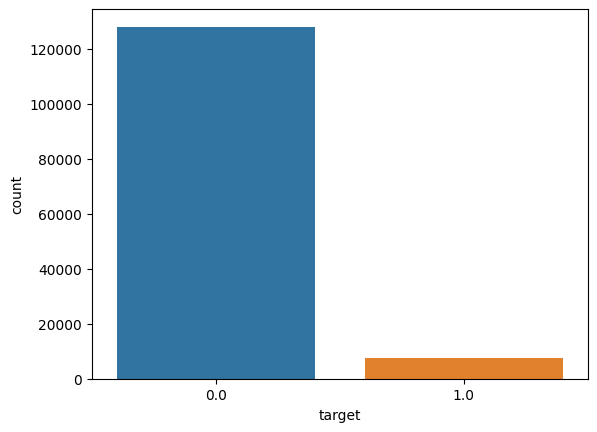

In [46]:
sns.countplot(x='target', data=df)
plt.show()

From this we can see that we are dealing with an imballaced data set

### Train Test Split

In [47]:
X = df.drop(columns=['target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

### EDA

In [48]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108394 entries, 75532 to 107653
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   disrict                         108394 non-null  int64  
 1   client_catg                     108394 non-null  int64  
 2   region                          108394 non-null  int64  
 3   Bill_Count                      108394 non-null  int64  
 4   creation_day                    108394 non-null  int64  
 5   creation_month                  108394 non-null  int64  
 6   creation_year                   108394 non-null  int64  
 7   avg_frequency_of_bills_in_days  108394 non-null  float64
 8   single_bill_client              108394 non-null  int64  
 9   tarif_type_mode                 108394 non-null  int64  
 10  counter_coefficient_mode        108394 non-null  int64  
 11  counter_type_mode               108394 non-null  object 
 12  reading_remarque_

In [49]:
# train dataframe shape
X_train.shape, y_train.shape

((108394, 24), (108394,))

In [50]:
# test dataframe shape
X_test.shape, y_test.shape

((27099, 24), (27099,))

In [51]:
y_train.value_counts(normalize=True)

target
0.0    0.944157
1.0    0.055843
Name: proportion, dtype: float64

In [52]:
y_test.value_counts(normalize=True)

target
0.0    0.944168
1.0    0.055832
Name: proportion, dtype: float64

In [53]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
disrict,108394.0,63.513220,3.353525,60.0,62.000000,62.000000,69.000000,69.000000
client_catg,108394.0,11.496697,4.352619,11.0,11.000000,11.000000,11.000000,51.000000
region,108394.0,206.284877,104.190688,101.0,103.000000,107.000000,307.000000,399.000000
Bill_Count,108394.0,33.128365,26.053858,1.0,11.000000,30.000000,50.000000,380.000000
creation_day,108394.0,17.459887,8.696937,1.0,10.000000,18.000000,25.000000,31.000000
creation_month,108394.0,7.283567,3.524422,1.0,4.000000,8.000000,11.000000,12.000000
creation_year,108394.0,2002.144971,11.562467,1977.0,1993.000000,2005.000000,2012.000000,2019.000000
avg_frequency_of_bills_in_days,108394.0,121.079278,86.433729,0.0,70.943658,117.612903,140.750000,3518.000000
single_bill_client,108394.0,0.031127,0.173662,0.0,0.000000,0.000000,0.000000,1.000000
tarif_type_mode,108394.0,12.920678,7.371767,9.0,11.000000,11.000000,11.000000,45.000000


In [54]:
X_train.isnull().sum()

disrict                              0
client_catg                          0
region                               0
Bill_Count                           0
creation_day                         0
creation_month                       0
creation_year                        0
avg_frequency_of_bills_in_days       0
single_bill_client                   0
tarif_type_mode                      0
counter_coefficient_mode             0
counter_type_mode                    0
reading_remarque_min                 0
reading_remarque_mode                0
consommation_level_1_mean            0
consommation_level_1_std          3374
consommation_level_2_mean            0
consommation_level_2_std          3374
consommation_level_3_mean            0
consommation_level_3_std          3374
consommation_level_4_mean            0
consommation_level_4_std          3374
diff_index_mean                      0
diff_index_std                    3374
dtype: int64

In [55]:
X_train = X_train.fillna(0)
X_train.isnull().sum()

disrict                           0
client_catg                       0
region                            0
Bill_Count                        0
creation_day                      0
creation_month                    0
creation_year                     0
avg_frequency_of_bills_in_days    0
single_bill_client                0
tarif_type_mode                   0
counter_coefficient_mode          0
counter_type_mode                 0
reading_remarque_min              0
reading_remarque_mode             0
consommation_level_1_mean         0
consommation_level_1_std          0
consommation_level_2_mean         0
consommation_level_2_std          0
consommation_level_3_mean         0
consommation_level_3_std          0
consommation_level_4_mean         0
consommation_level_4_std          0
diff_index_mean                   0
diff_index_std                    0
dtype: int64

In [56]:
X_test = X_test.fillna(0)
X_test.isnull().sum()

disrict                           0
client_catg                       0
region                            0
Bill_Count                        0
creation_day                      0
creation_month                    0
creation_year                     0
avg_frequency_of_bills_in_days    0
single_bill_client                0
tarif_type_mode                   0
counter_coefficient_mode          0
counter_type_mode                 0
reading_remarque_min              0
reading_remarque_mode             0
consommation_level_1_mean         0
consommation_level_1_std          0
consommation_level_2_mean         0
consommation_level_2_std          0
consommation_level_3_mean         0
consommation_level_3_std          0
consommation_level_4_mean         0
consommation_level_4_std          0
diff_index_mean                   0
diff_index_std                    0
dtype: int64

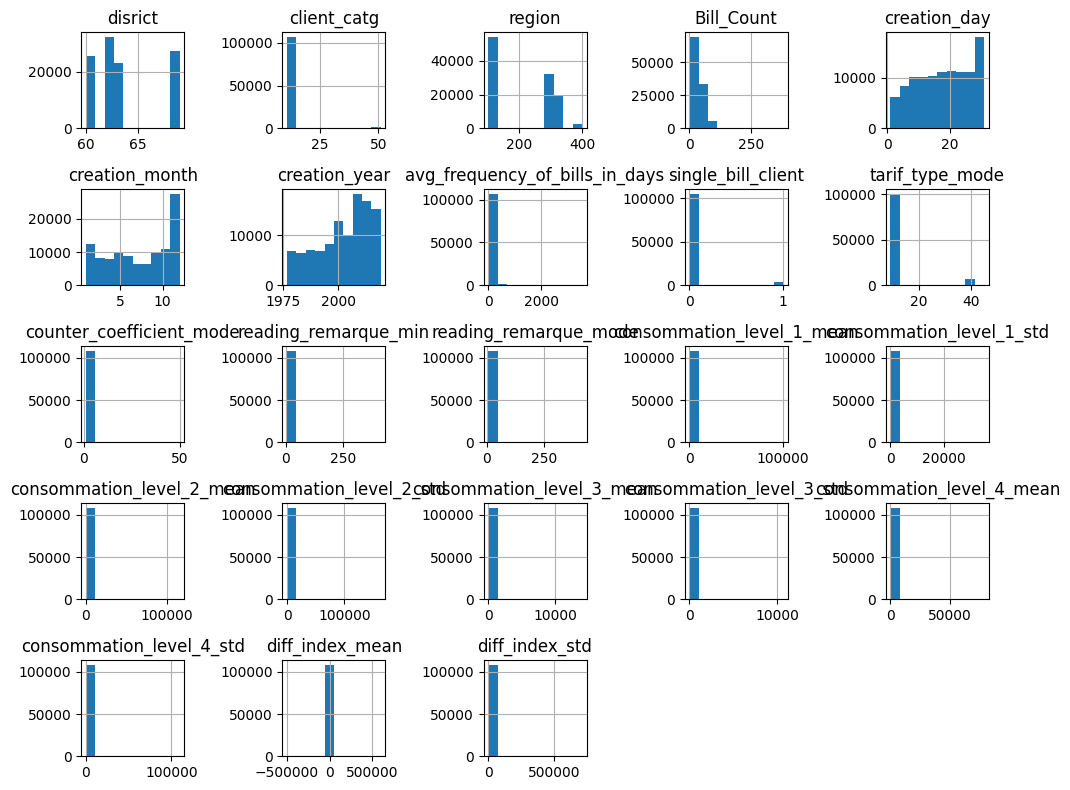

In [57]:
X_train.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

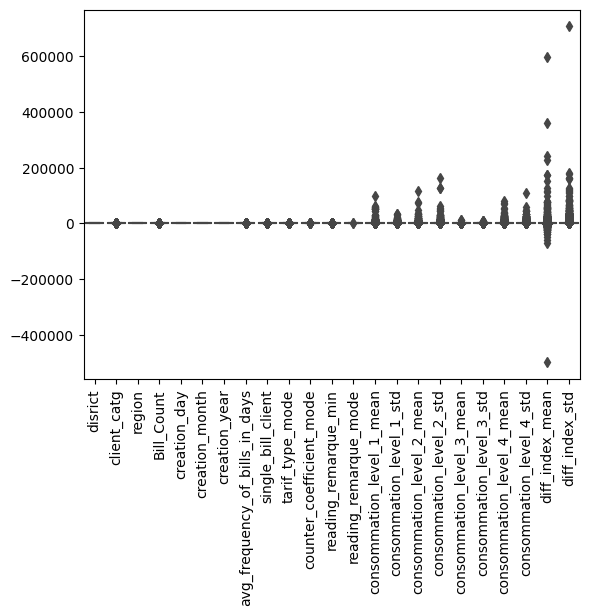

In [58]:
sns.boxplot(data=X_train)
plt.xticks(rotation=90)
plt.show()

In [59]:
X_train.columns

Index(['disrict', 'client_catg', 'region', 'Bill_Count', 'creation_day',
       'creation_month', 'creation_year', 'avg_frequency_of_bills_in_days',
       'single_bill_client', 'tarif_type_mode', 'counter_coefficient_mode',
       'counter_type_mode', 'reading_remarque_min', 'reading_remarque_mode',
       'consommation_level_1_mean', 'consommation_level_1_std',
       'consommation_level_2_mean', 'consommation_level_2_std',
       'consommation_level_3_mean', 'consommation_level_3_std',
       'consommation_level_4_mean', 'consommation_level_4_std',
       'diff_index_mean', 'diff_index_std'],
      dtype='object')

### EDA for categorical variables

In [60]:
categorical_cols = [
    'disrict',
    'client_catg',
    'region',
    'tarif_type_mode',
    'counter_coefficient_mode',
    'counter_type_mode',
    'reading_remarque_min',
    'reading_remarque_mode',
    'single_bill_client'
]
categorical_data = X_train[categorical_cols]
categorical_data.head()

,disrict,client_catg,region,tarif_type_mode,counter_coefficient_mode,counter_type_mode,reading_remarque_min,reading_remarque_mode,single_bill_client
75532,69,11,105,11,1,ELEC,8,9,0
123094,69,11,107,11,1,ELEC,6,6,0
114229,60,11,101,11,1,ELEC,6,6,0
48514,60,11,101,11,1,ELEC,6,9,0
130130,62,11,301,11,1,ELEC,6,6,0


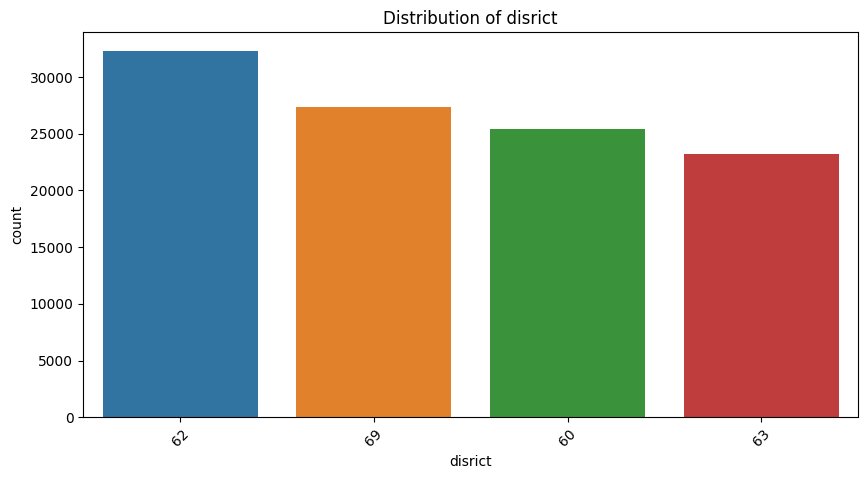

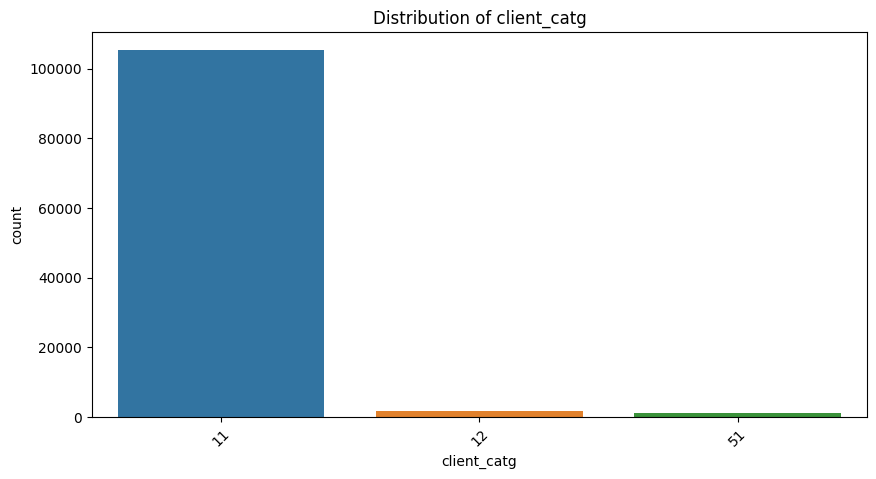

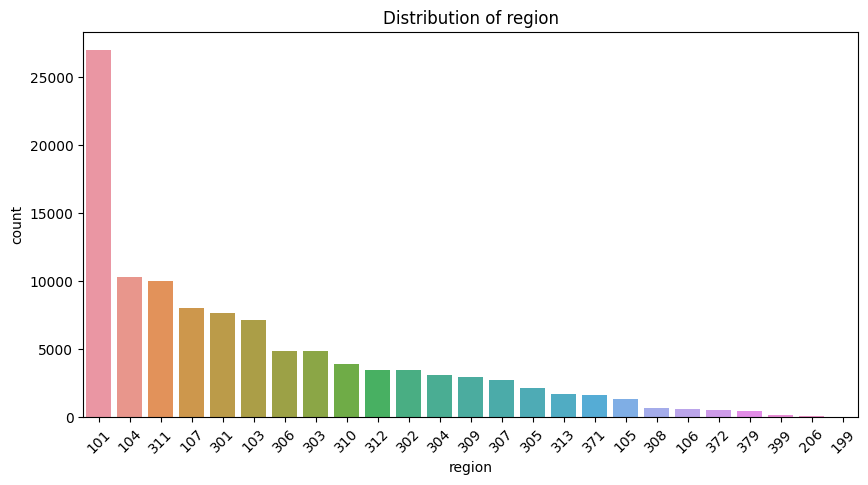

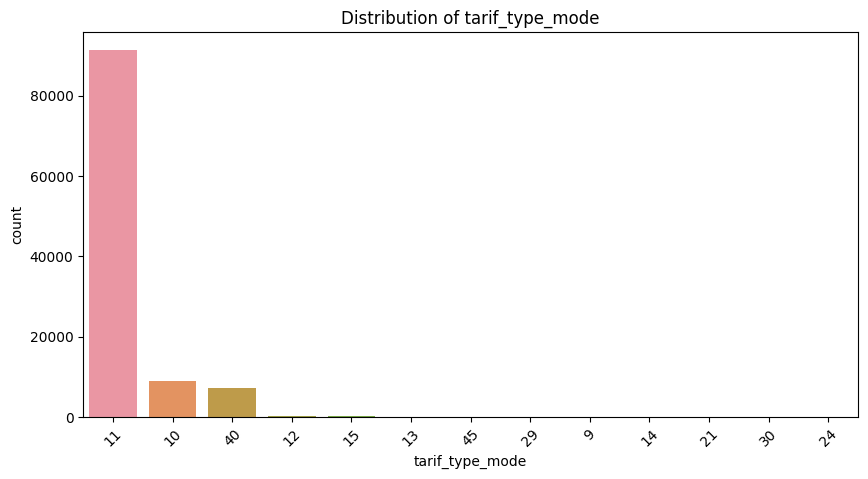

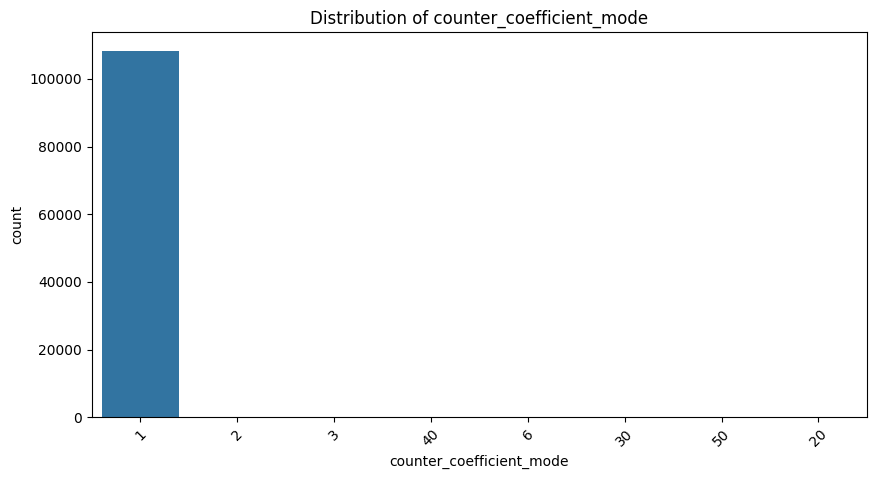

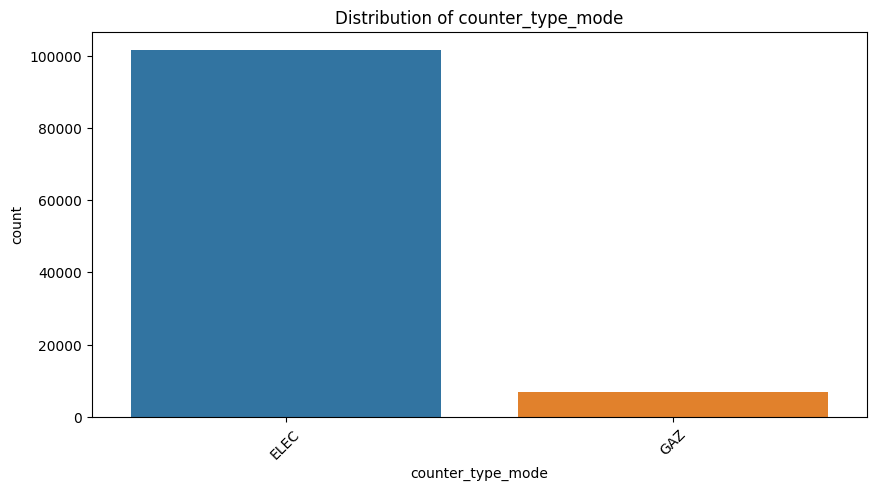

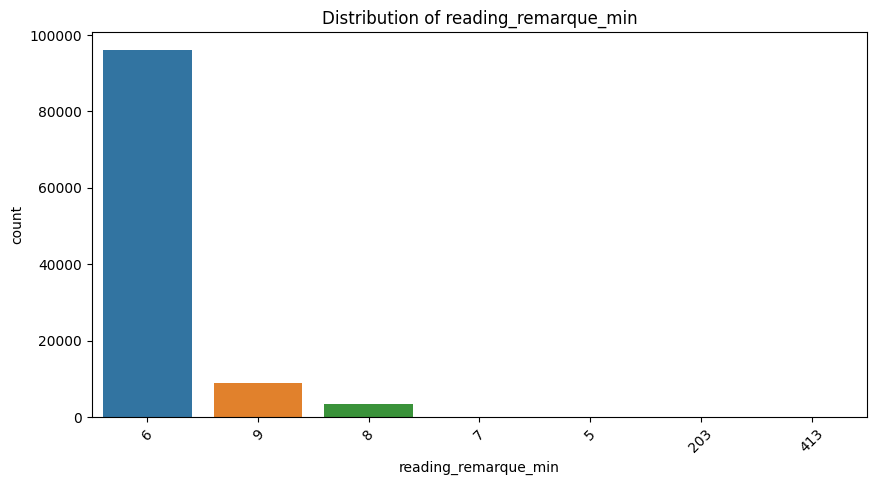

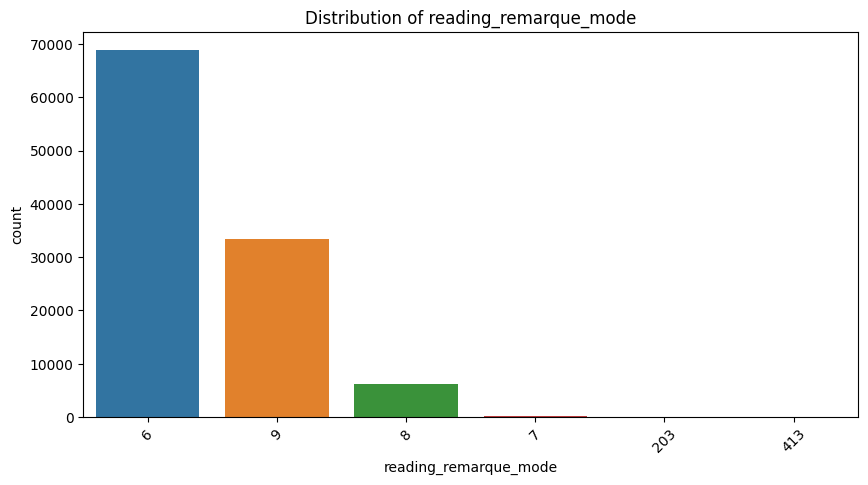

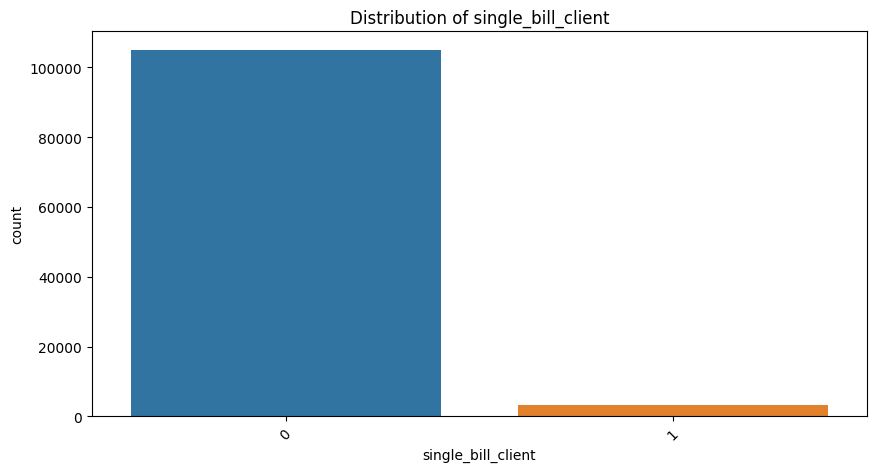

In [61]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=X_train, order=X_train[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

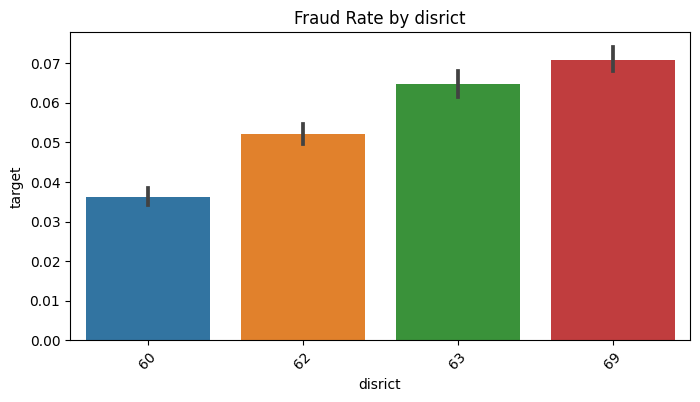

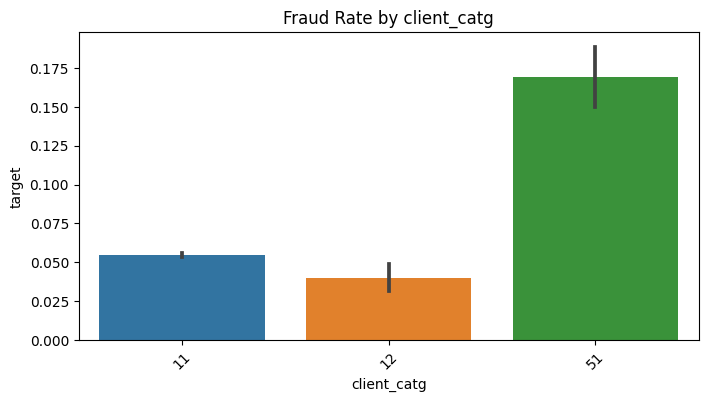

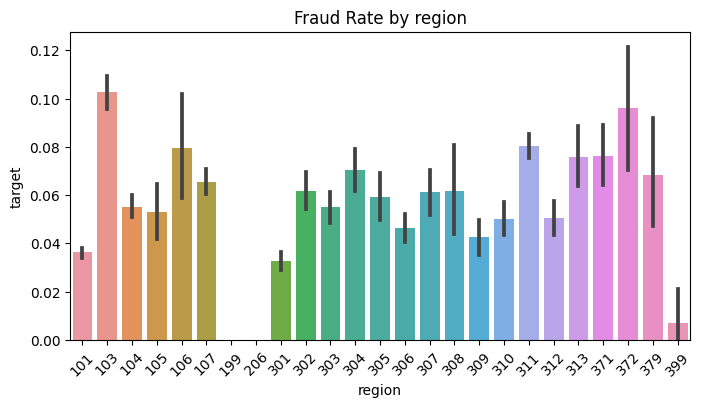

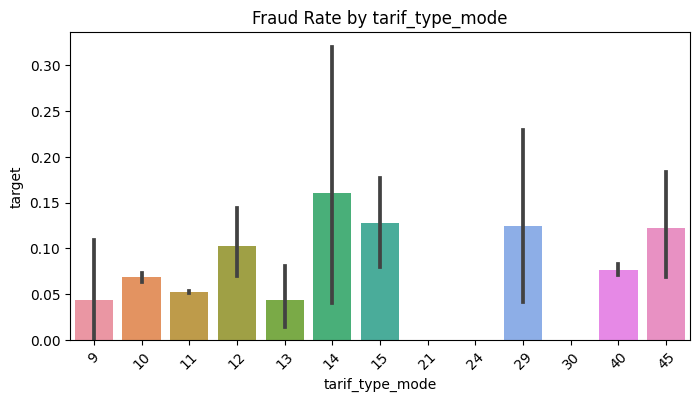

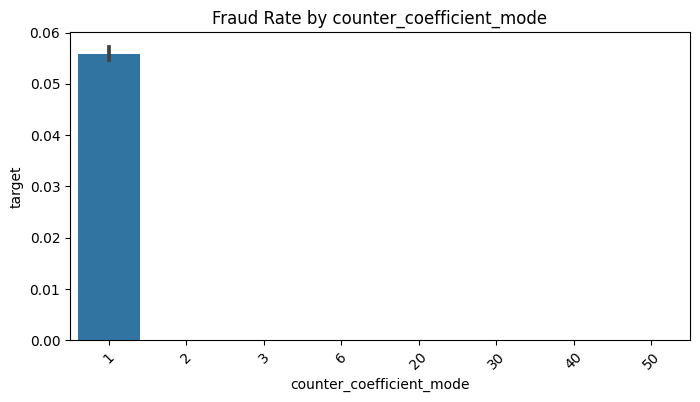

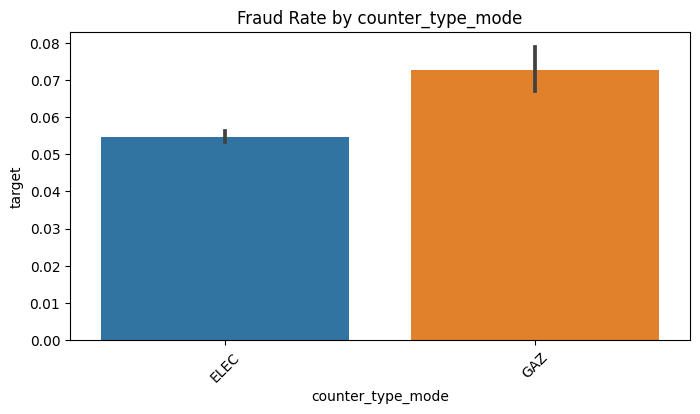

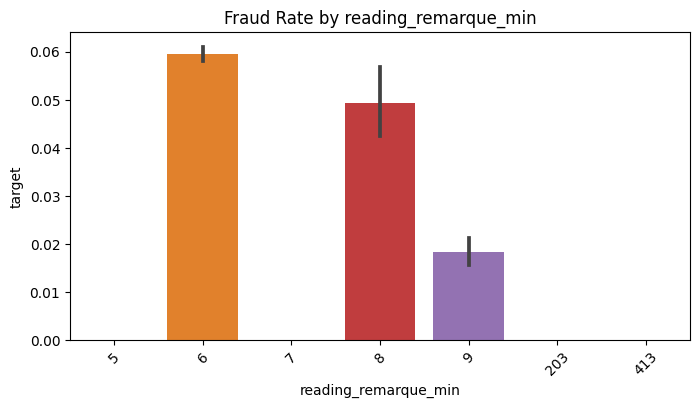

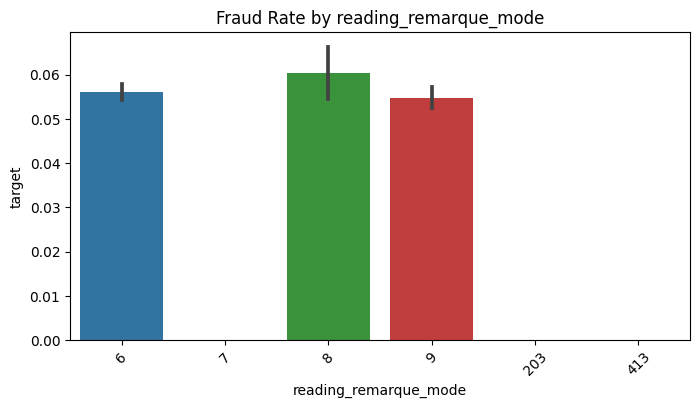

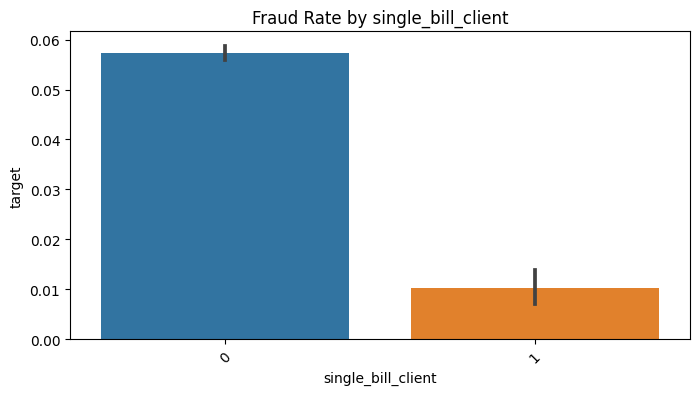

In [62]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=X_train, x=col, y=y_train)  # Replace `y_train` with your target variable
    plt.title(f'Fraud Rate by {col}')
    plt.xticks(rotation=45)
    plt.show()

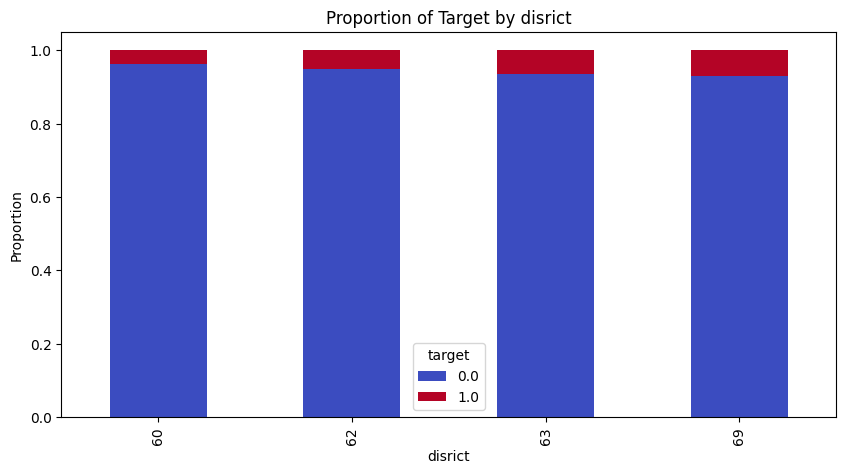

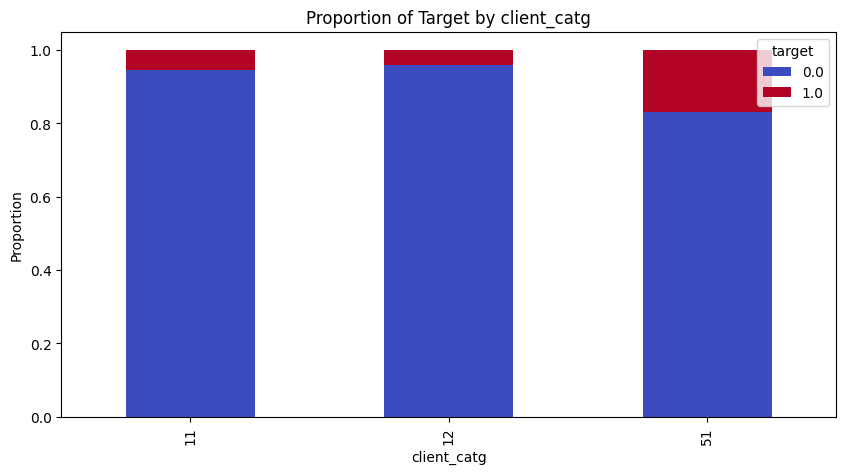

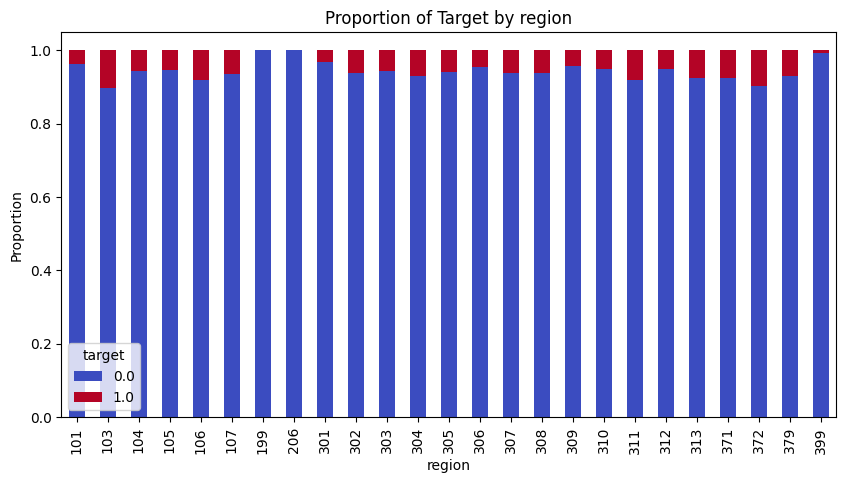

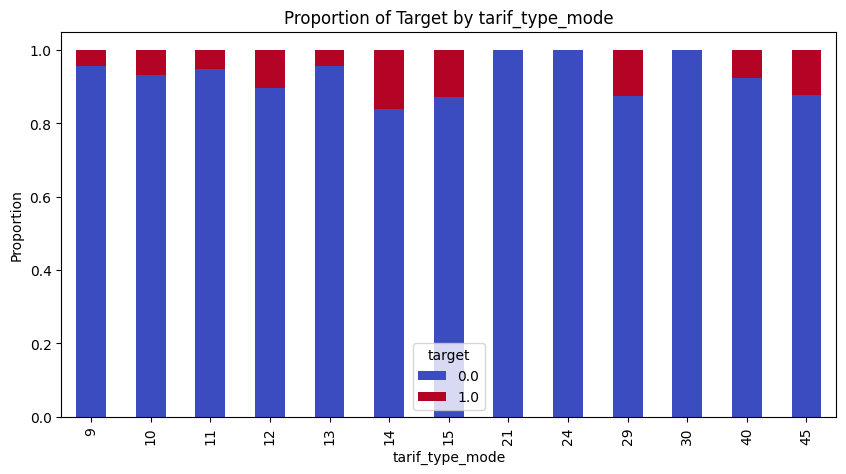

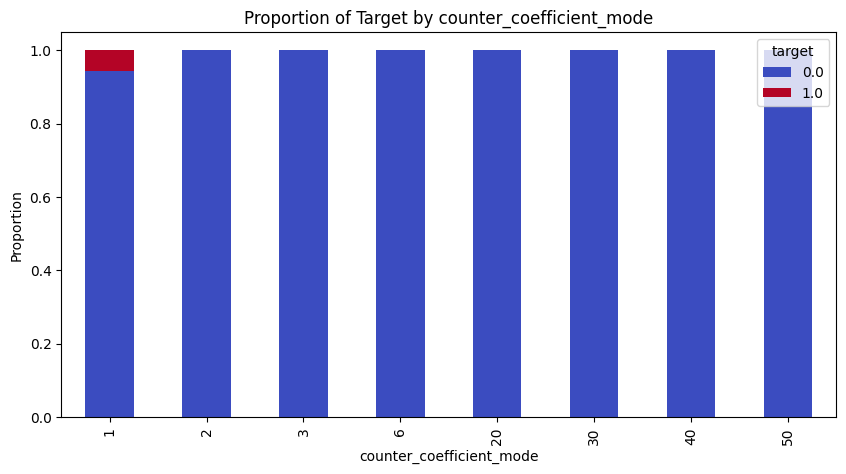

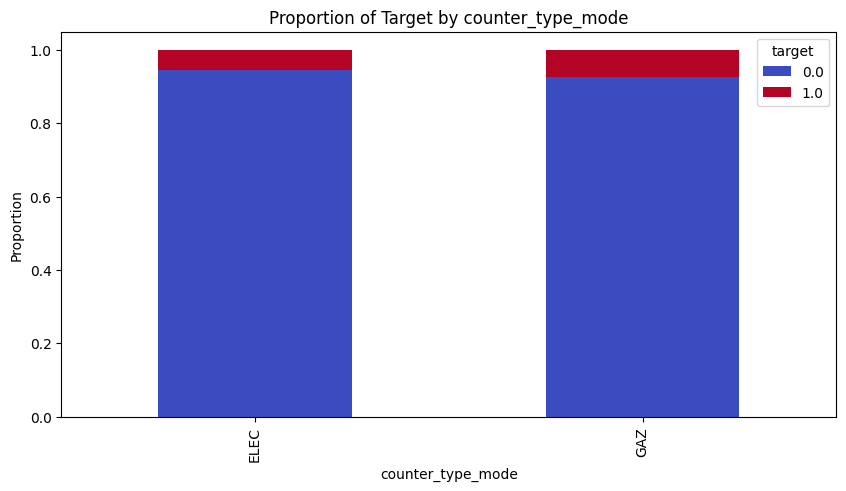

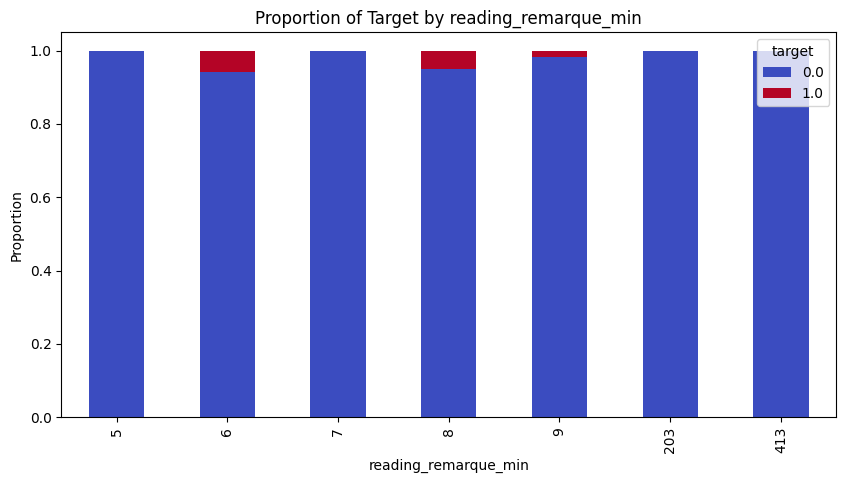

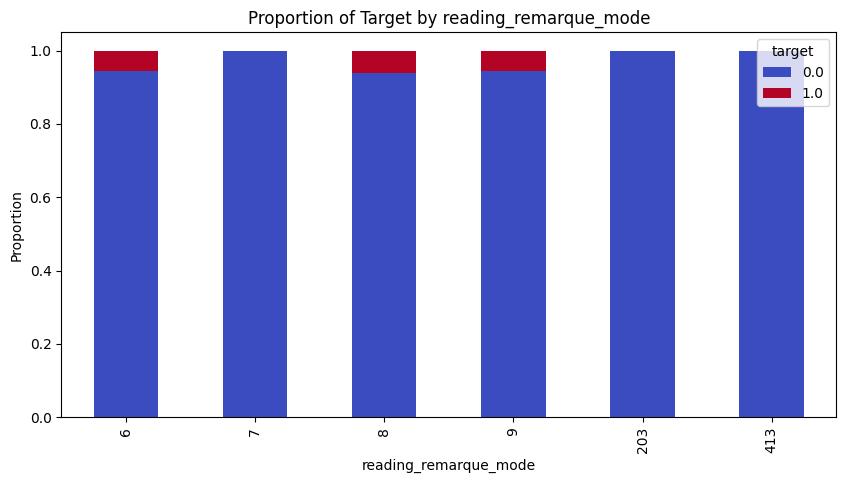

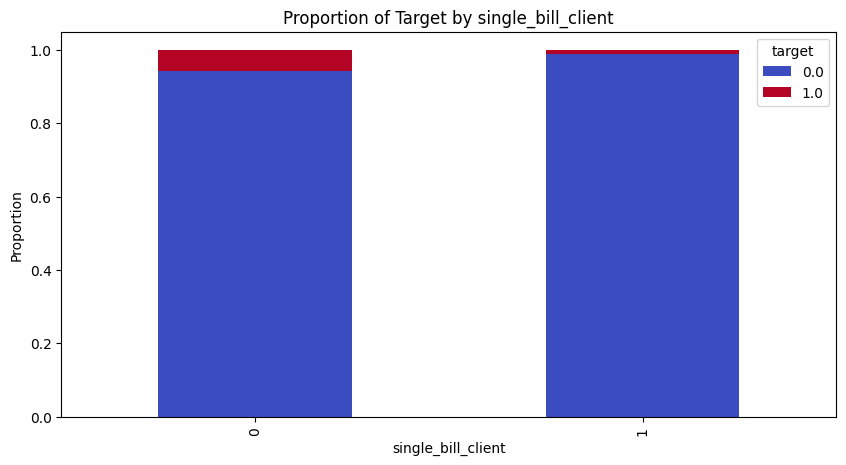

In [63]:
#X_train['target'] = y_train  # Combine for analysis

for col in categorical_cols:
    cross_tab = pd.crosstab(X_train[col], y_train, normalize='index')
    cross_tab.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='coolwarm')
    plt.title(f"Proportion of Target by {col}")
    plt.ylabel('Proportion')
    plt.show()

# Drop the target column afterward if modifying X_train directly
#X_train.drop('target', axis=1, inplace=True)

In [64]:
from scipy.stats import chi2_contingency

for col in categorical_cols:
    contingency_table = pd.crosstab(X_train[col], y_train)
    chi2_stat, p_value, dof, _ = chi2_contingency(contingency_table)
    print(f"Chi-Square Test for {col}:\nChi2 Statistic: {chi2_stat}, P-value: {p_value}\n")

Chi-Square Test for disrict:
Chi2 Statistic: 349.4436740142649, P-value: 1.9685048912689652e-75

Chi-Square Test for client_catg:
Chi2 Statistic: 329.02300831505556, P-value: 3.5773508413758017e-72

Chi-Square Test for region:
Chi2 Statistic: 797.0912845232642, P-value: 8.512425866845185e-153

Chi-Square Test for tarif_type_mode:
Chi2 Statistic: 155.17099893604484, P-value: 5.0500723335800554e-27

Chi-Square Test for counter_coefficient_mode:
Chi2 Statistic: 1.6564992709710218, P-value: 0.9763922198620337

Chi-Square Test for counter_type_mode:
Chi2 Statistic: 39.80322960337861, P-value: 2.8088026961352305e-10

Chi-Square Test for reading_remarque_min:
Chi2 Statistic: 272.2918625291895, P-value: 7.013459077700374e-56

Chi-Square Test for reading_remarque_mode:
Chi2 Statistic: 9.277030156690685, P-value: 0.09851160218438017

Chi-Square Test for single_bill_client:
Chi2 Statistic: 135.66450927825002, P-value: 2.3625922033940954e-31



In [65]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 != col2:
            score = cramers_v(X_train[col1], X_train[col2])
            print(f"Cramér's V between {col1} and {col2}: {score}")

Cramér's V between disrict and client_catg: 0.037087647269529685
Cramér's V between disrict and region: 0.9804741121987023
Cramér's V between disrict and tarif_type_mode: 0.12232208345708633
Cramér's V between disrict and counter_coefficient_mode: 0.01474627589459556
Cramér's V between disrict and counter_type_mode: 0.09069862669205565
Cramér's V between disrict and reading_remarque_min: 0.0435131361560417
Cramér's V between disrict and reading_remarque_mode: 0.07081928320703677
Cramér's V between disrict and single_bill_client: 0.04387699267659306
Cramér's V between client_catg and disrict: 0.037087647269529685
Cramér's V between client_catg and region: 0.057231326476504356
Cramér's V between client_catg and tarif_type_mode: 0.10246354866896266
Cramér's V between client_catg and counter_coefficient_mode: 0.04571006306078685
Cramér's V between client_catg and counter_type_mode: 0.016478154577035335
Cramér's V between client_catg and reading_remarque_min: 0.03585958807617797
Cramér's V 

In [66]:
for col in categorical_cols:
    unique_count = X_train[col].nunique()
    print(f"{col}: {unique_count} unique values")

disrict: 4 unique values
client_catg: 3 unique values
region: 25 unique values
tarif_type_mode: 13 unique values
counter_coefficient_mode: 8 unique values
counter_type_mode: 2 unique values
reading_remarque_min: 7 unique values
reading_remarque_mode: 6 unique values
single_bill_client: 2 unique values


In [67]:
for col in categorical_cols:
    print(f"Unique values in {col}:\n{X_train[col].unique()}\n")

Unique values in disrict:
[69 60 62 63]

Unique values in client_catg:
[11 12 51]

Unique values in region:
[105 107 101 301 306 311 307 303 104 310 106 103 371 304 312 372 305 313
 302 309 379 308 206 399 199]

Unique values in tarif_type_mode:
[11 10 40 15 12  9 13 45 14 29 21 24 30]

Unique values in counter_coefficient_mode:
[ 1 40  2 30  3 50  6 20]

Unique values in counter_type_mode:
['ELEC' 'GAZ']

Unique values in reading_remarque_min:
[  8   6   9   7   5 203 413]

Unique values in reading_remarque_mode:
[  9   6   8   7 203 413]

Unique values in single_bill_client:
[0 1]



### EDA on Numerical Data

In [68]:
numeric_cols = ['Bill_Count', 'creation_day', 'creation_month', 
                'creation_year', 'avg_frequency_of_bills_in_days',
                'consommation_level_1_mean', 'consommation_level_1_std', 
                'consommation_level_2_mean', 'consommation_level_2_std', 
                'consommation_level_3_mean', 'consommation_level_3_std',
                'consommation_level_4_mean', 'consommation_level_4_std',
                'diff_index_mean', 'diff_index_std']


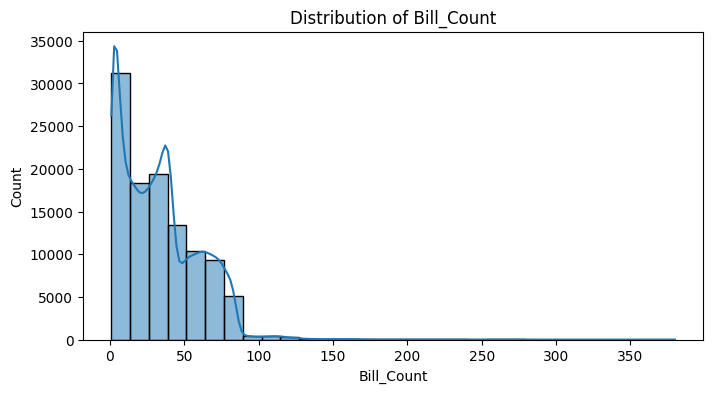

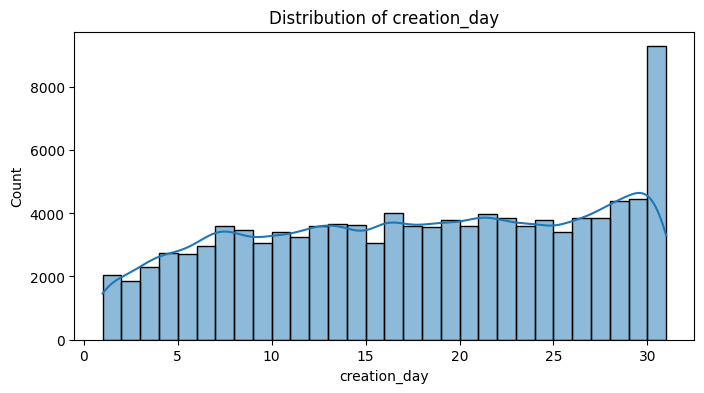

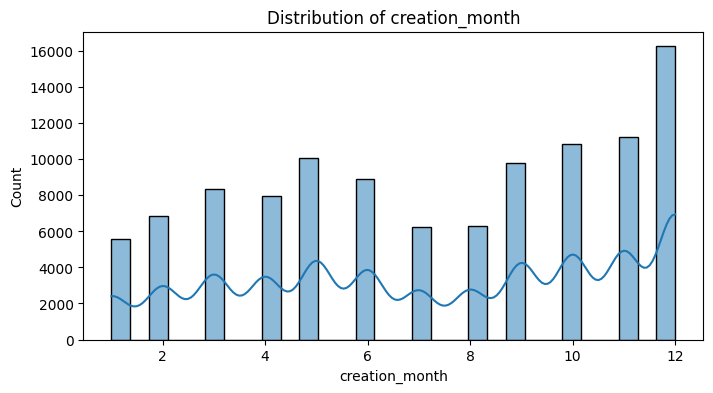

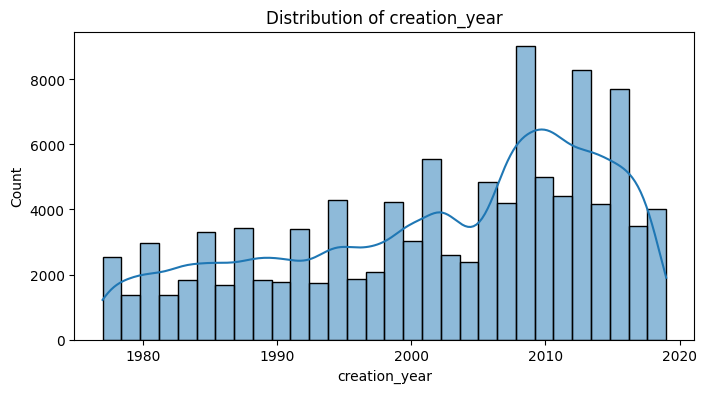

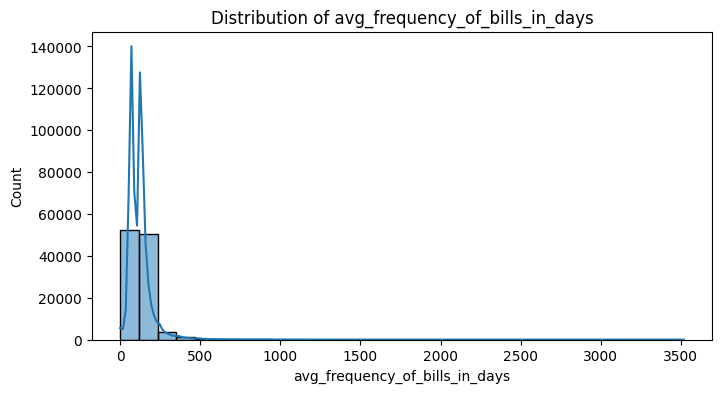

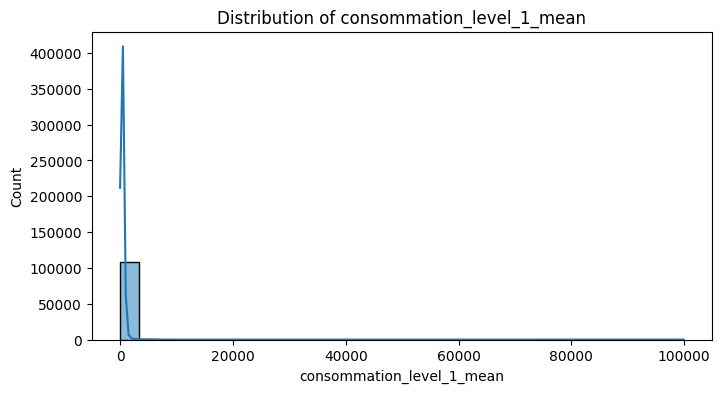

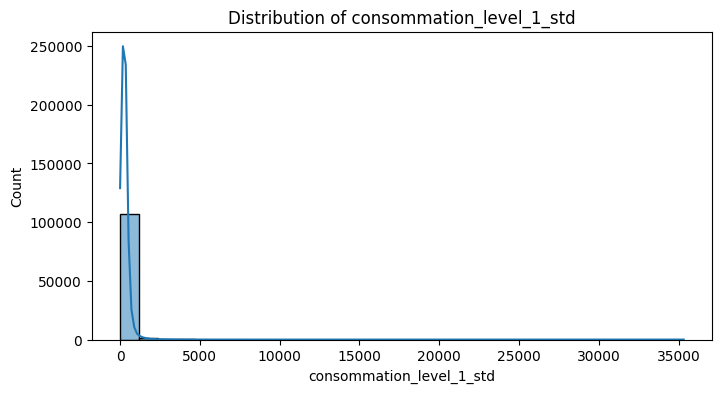

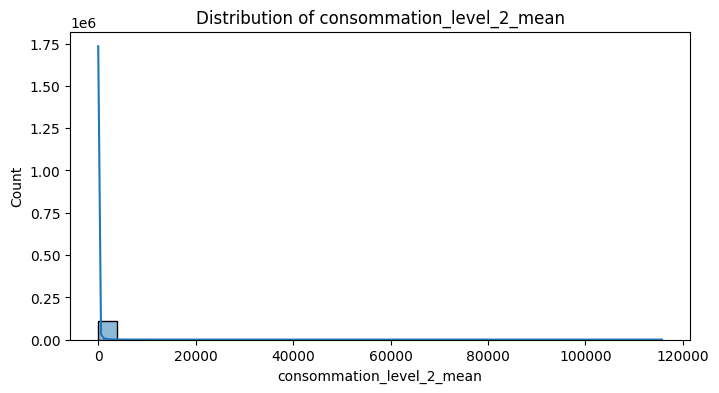

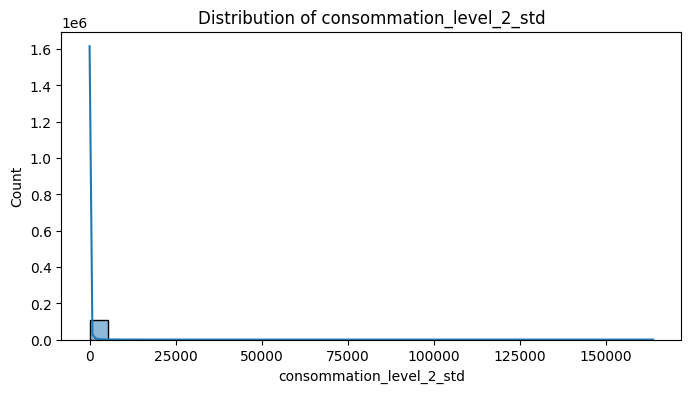

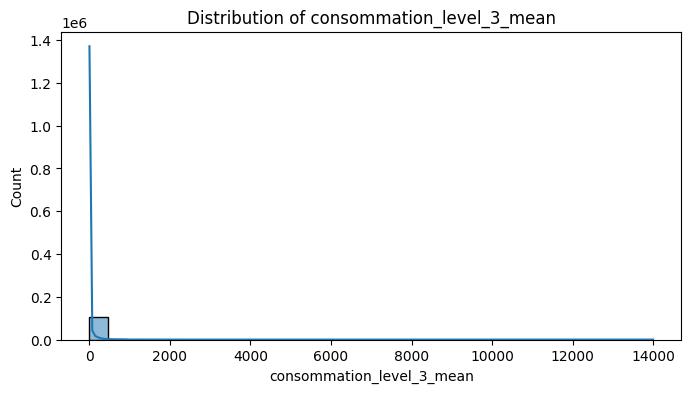

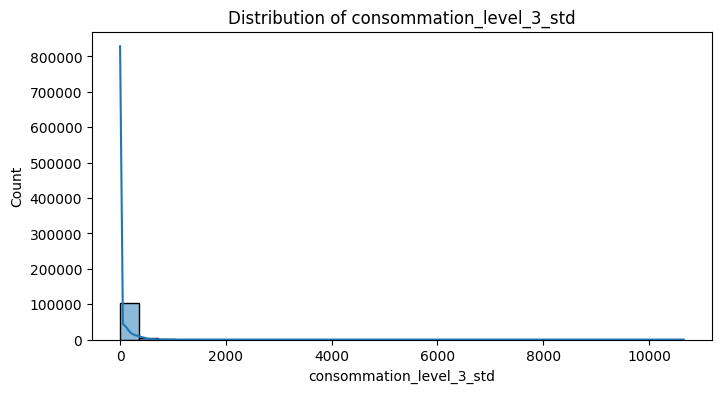

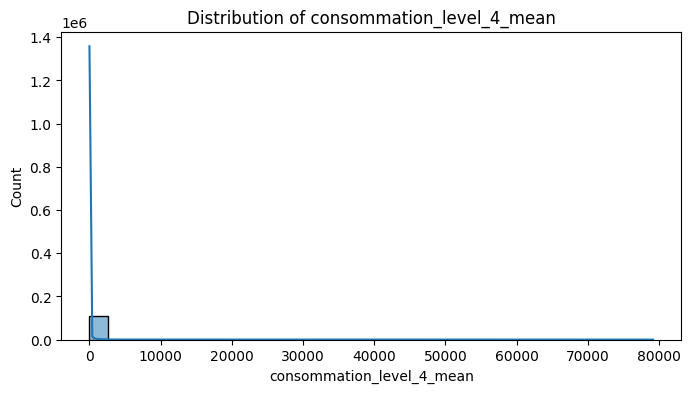

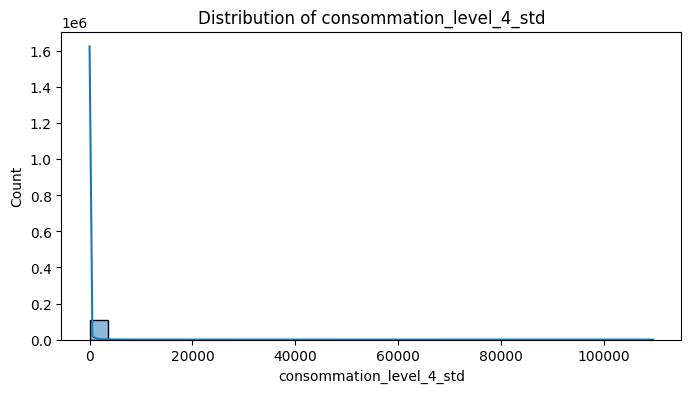

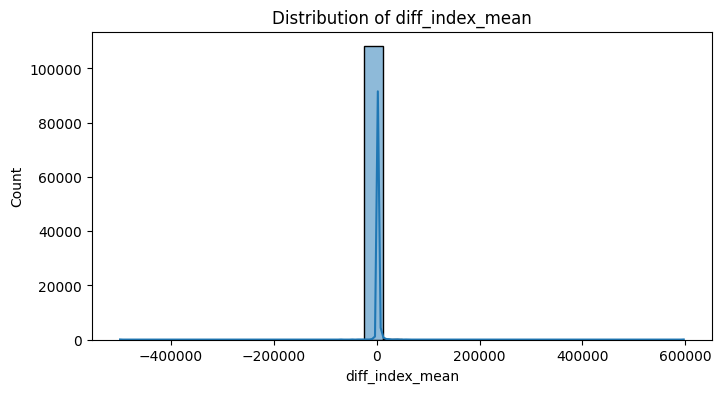

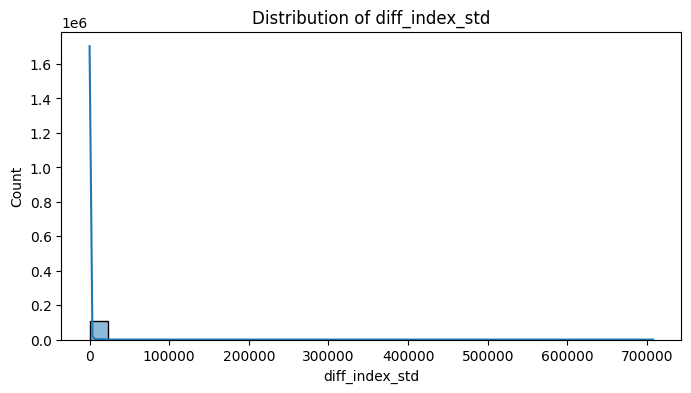

In [69]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_train[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

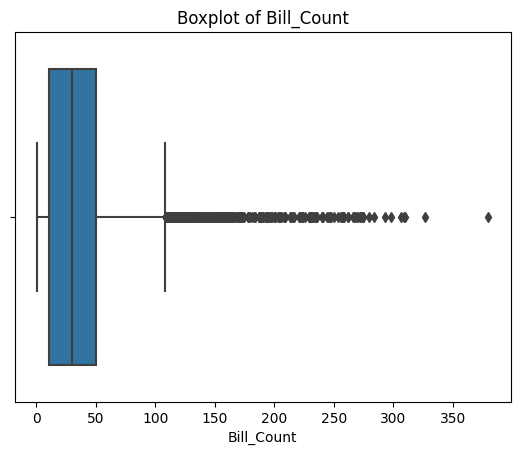

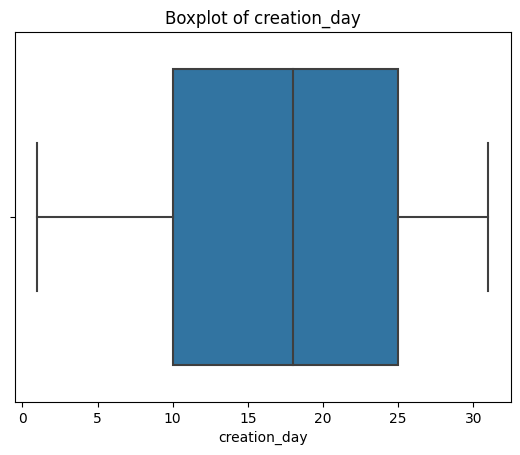

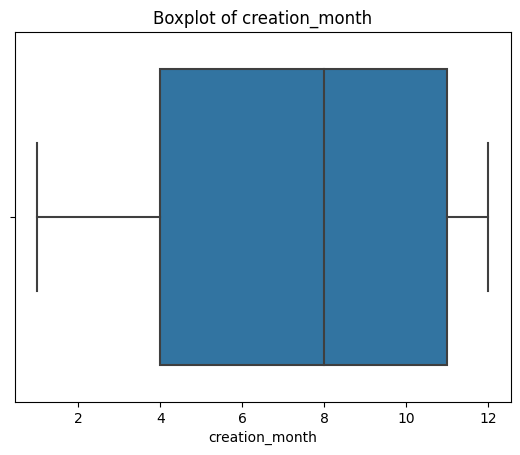

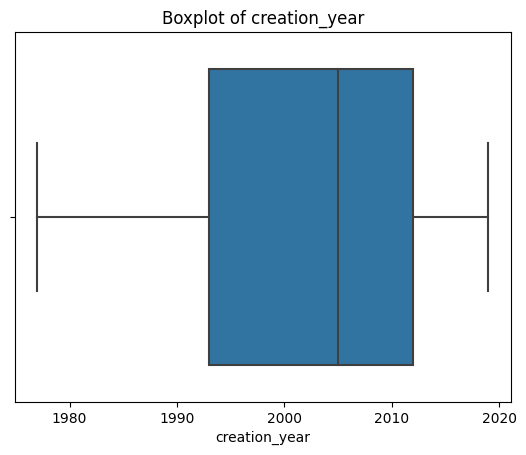

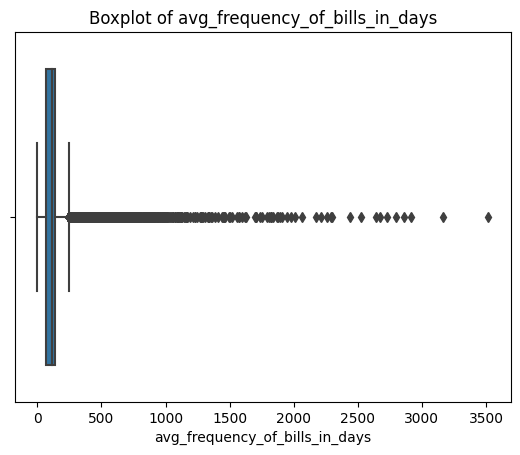

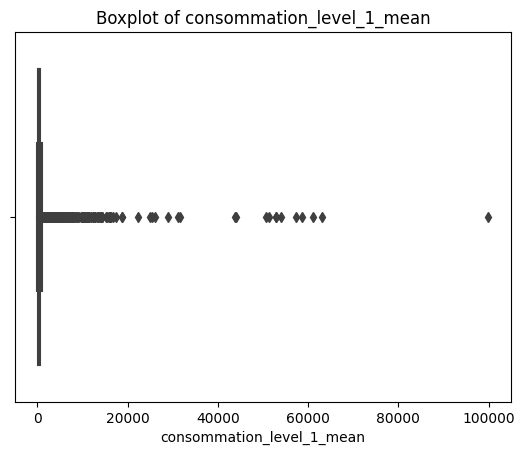

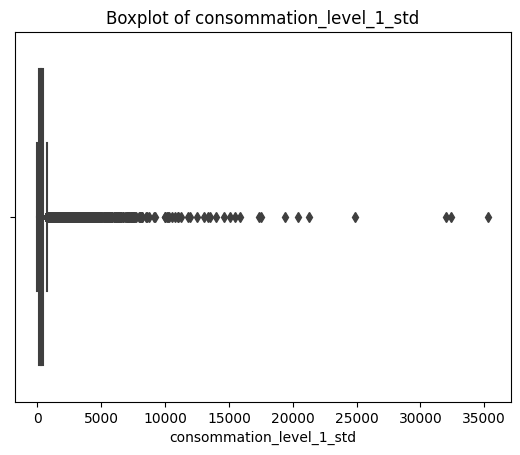

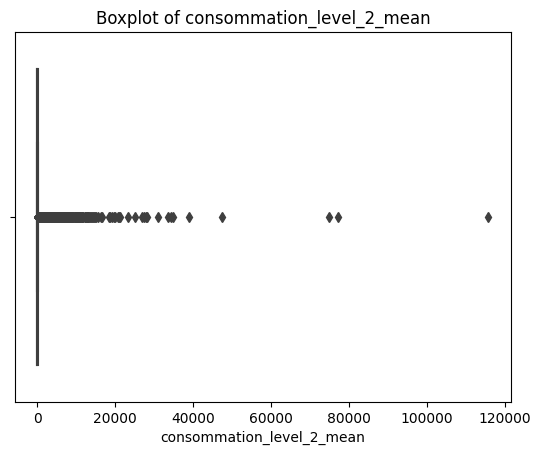

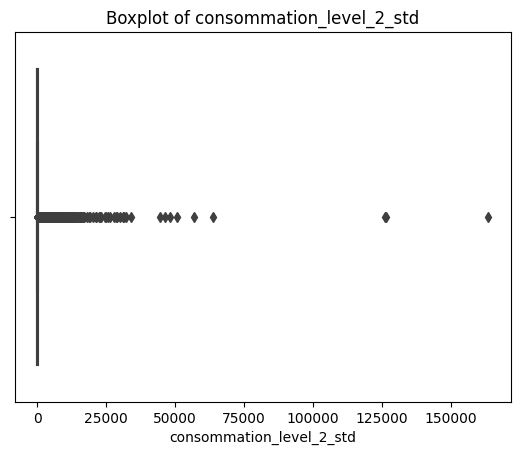

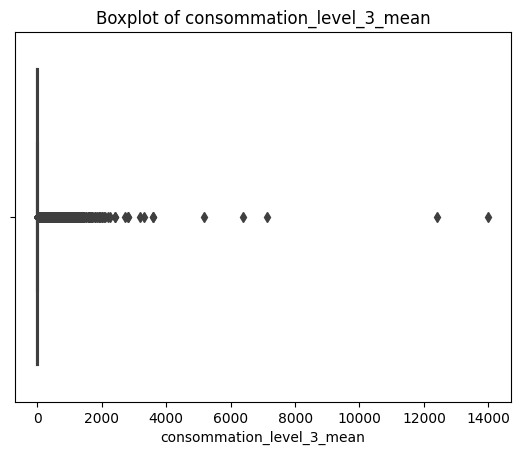

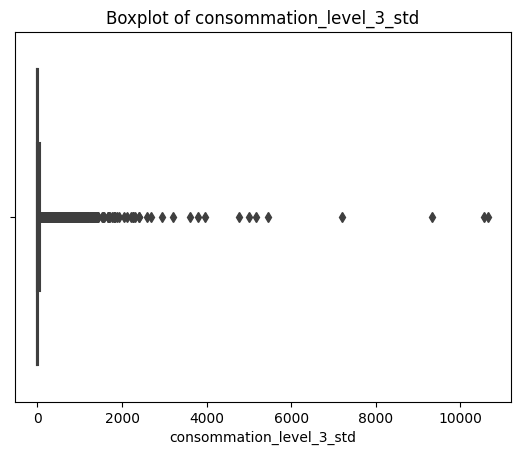

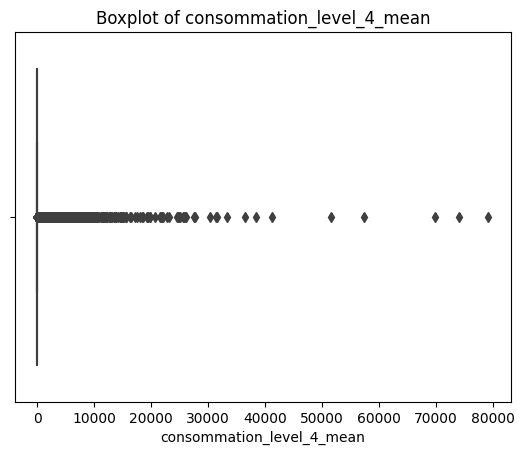

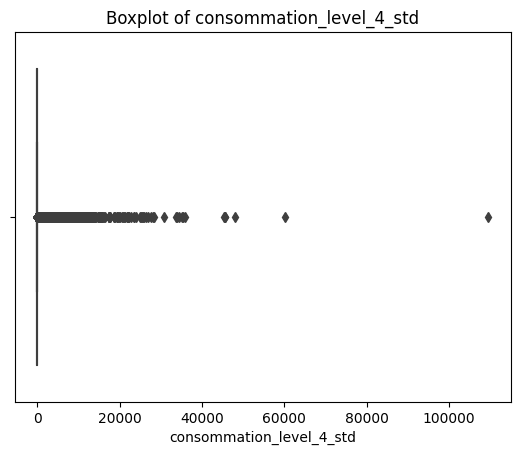

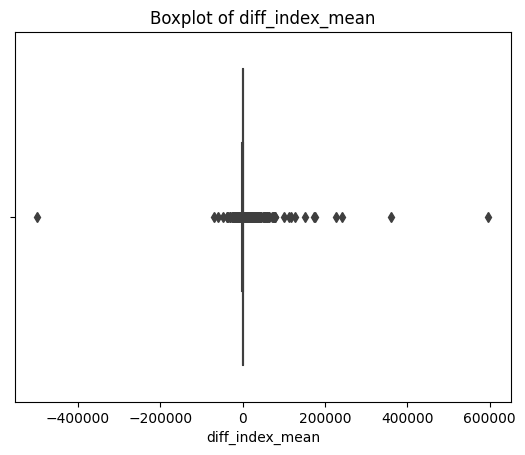

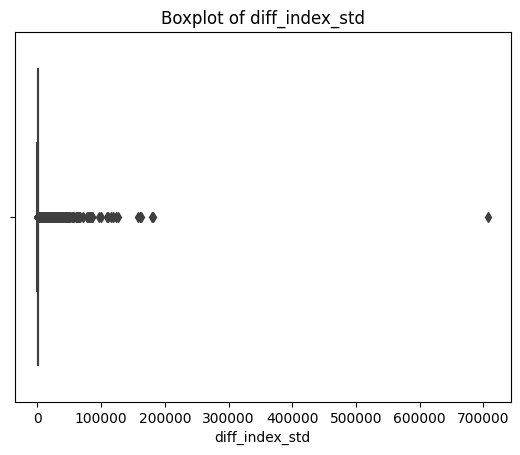

In [70]:
for col in numeric_cols:  
    sns.boxplot(x=X_train[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Bill_Count
count    108394.000000
mean         33.128365
std          26.053858
min           1.000000
25%          11.000000
50%          30.000000
75%          50.000000
max         380.000000
Name: Bill_Count, dtype: float64


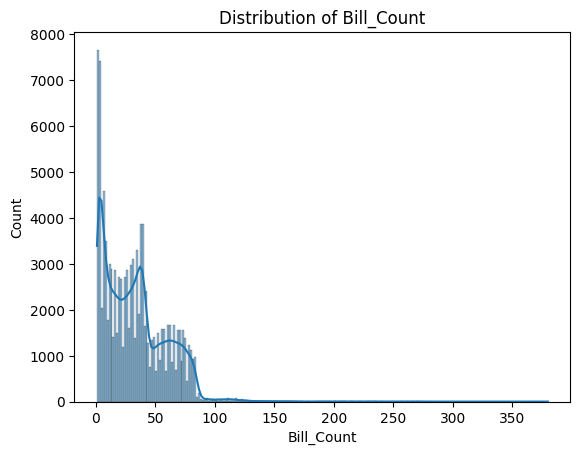

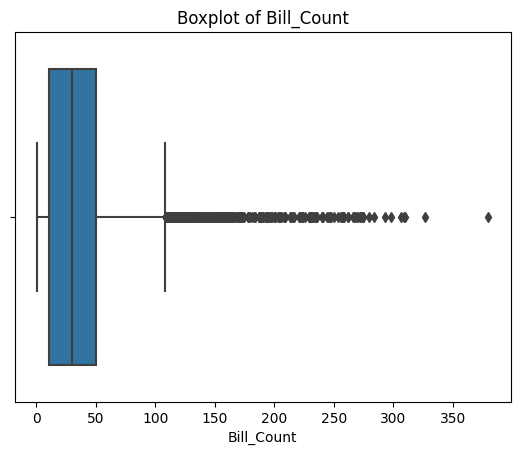

-----------------------------
creation_day
count    108394.000000
mean         17.459887
std           8.696937
min           1.000000
25%          10.000000
50%          18.000000
75%          25.000000
max          31.000000
Name: creation_day, dtype: float64


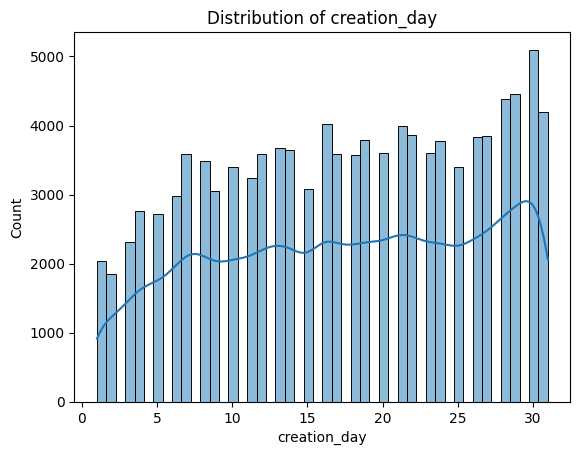

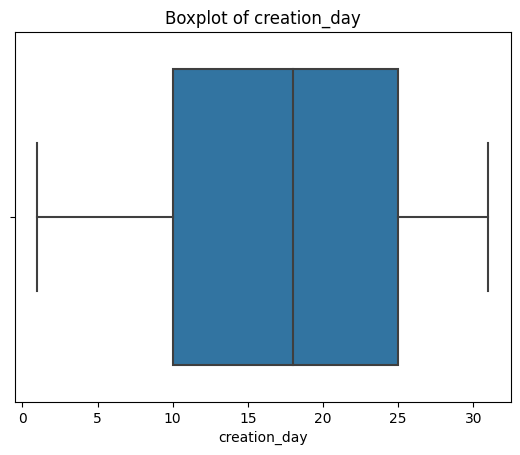

-----------------------------
creation_month
count    108394.000000
mean          7.283567
std           3.524422
min           1.000000
25%           4.000000
50%           8.000000
75%          11.000000
max          12.000000
Name: creation_month, dtype: float64


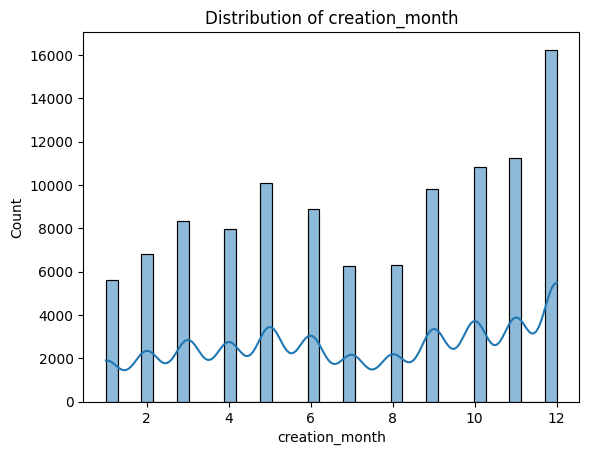

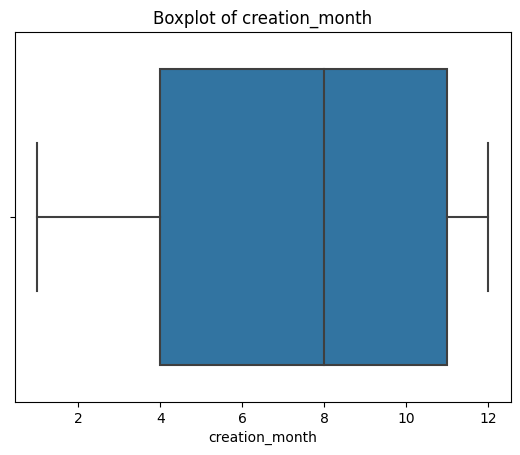

-----------------------------
creation_year
count    108394.000000
mean       2002.144971
std          11.562467
min        1977.000000
25%        1993.000000
50%        2005.000000
75%        2012.000000
max        2019.000000
Name: creation_year, dtype: float64


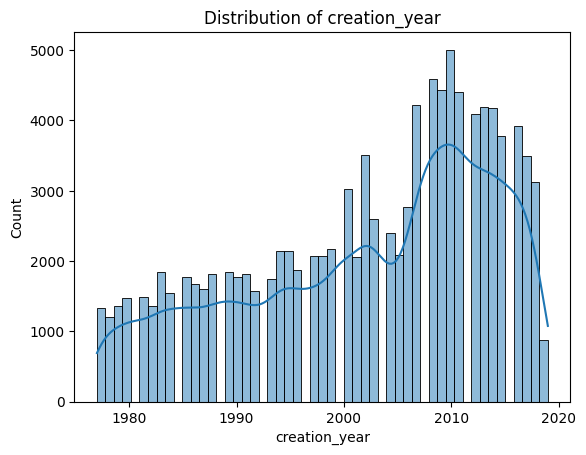

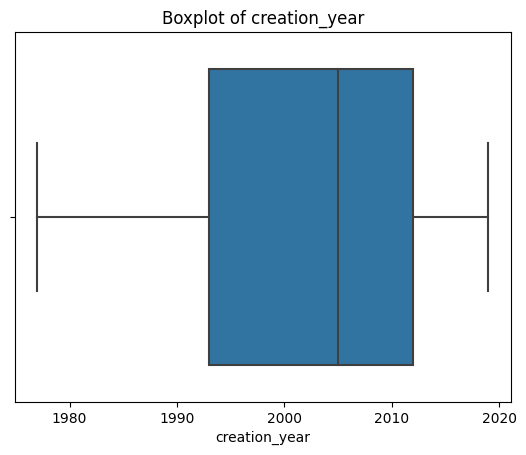

-----------------------------
avg_frequency_of_bills_in_days
count    108394.000000
mean        121.079278
std          86.433729
min           0.000000
25%          70.943658
50%         117.612903
75%         140.750000
max        3518.000000
Name: avg_frequency_of_bills_in_days, dtype: float64


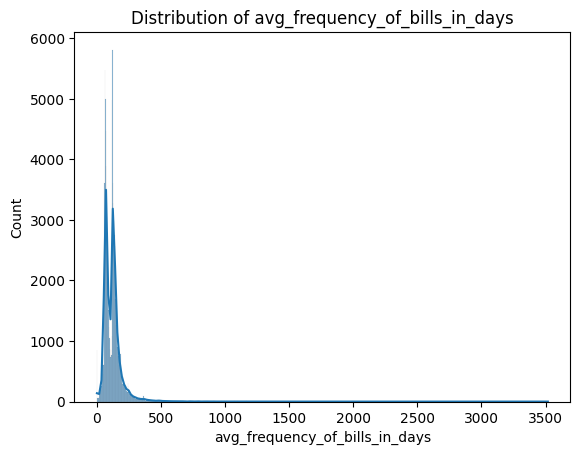

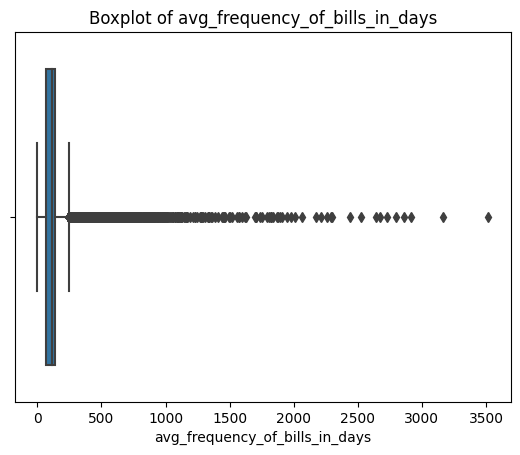

-----------------------------
consommation_level_1_mean
count    108394.000000
mean        433.394631
std         800.785302
min           0.000000
25%         216.000000
50%         356.078462
75%         541.965278
max       99920.000000
Name: consommation_level_1_mean, dtype: float64


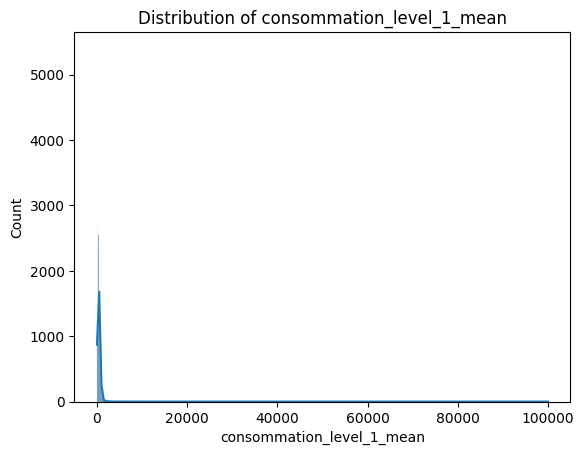

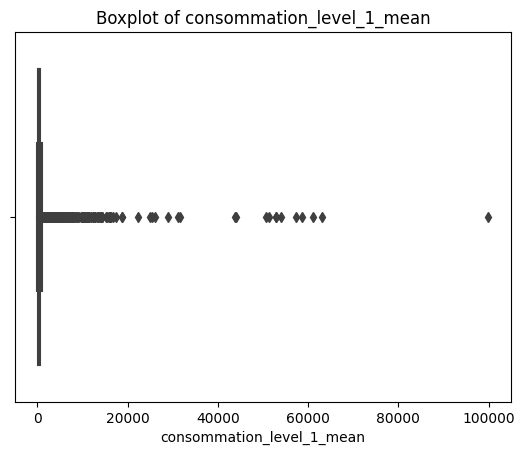

-----------------------------
consommation_level_1_std
count    108394.000000
mean        322.999212
std         441.139486
min           0.000000
25%         161.766285
50%         273.660545
75%         400.000000
max       35319.220896
Name: consommation_level_1_std, dtype: float64


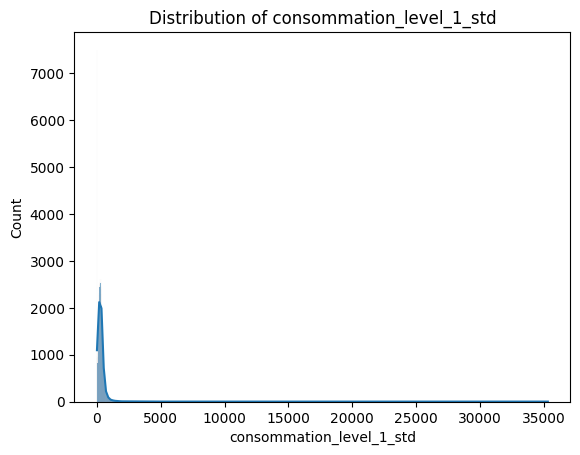

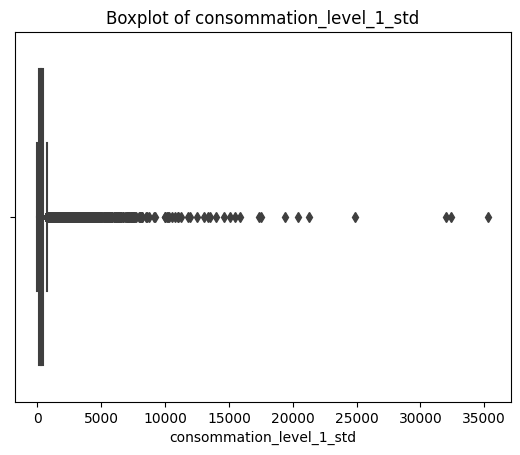

-----------------------------
consommation_level_2_mean
count    108394.000000
mean        115.219999
std         761.672712
min           0.000000
25%           0.000000
50%           5.035714
75%          63.313231
max      115683.000000
Name: consommation_level_2_mean, dtype: float64


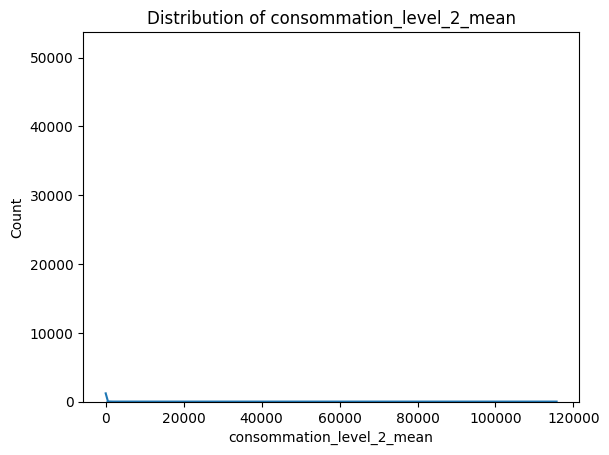

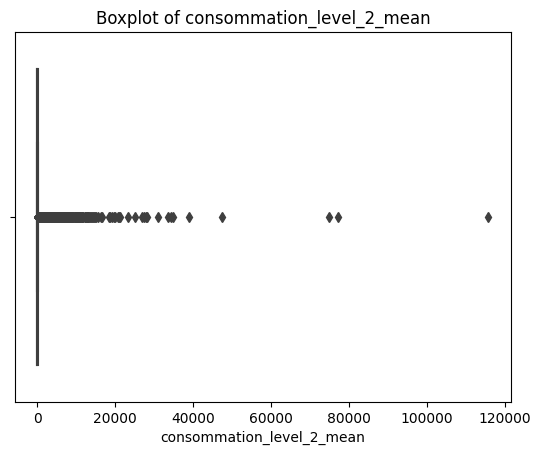

-----------------------------
consommation_level_2_std
count    108394.000000
mean        170.713664
std        1053.342026
min           0.000000
25%           0.000000
50%          24.633832
75%         141.524808
max      163705.093298
Name: consommation_level_2_std, dtype: float64


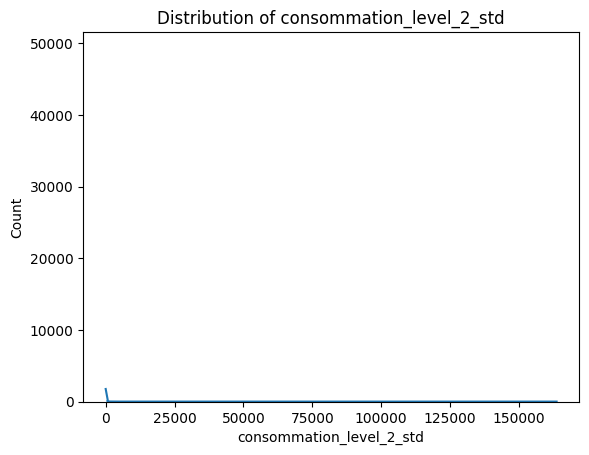

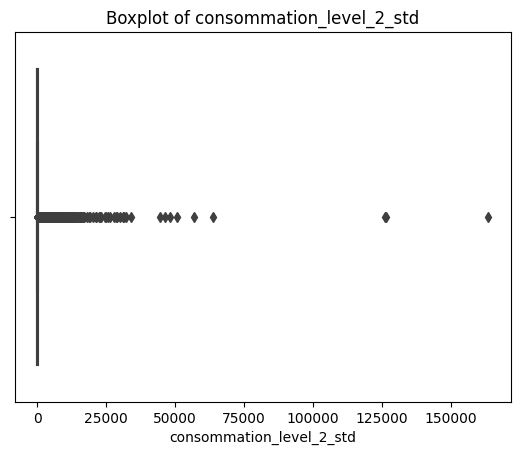

-----------------------------
consommation_level_3_mean
count    108394.000000
mean         27.265149
std         120.315023
min           0.000000
25%           0.000000
50%           0.000000
75%           4.000000
max       14000.000000
Name: consommation_level_3_mean, dtype: float64


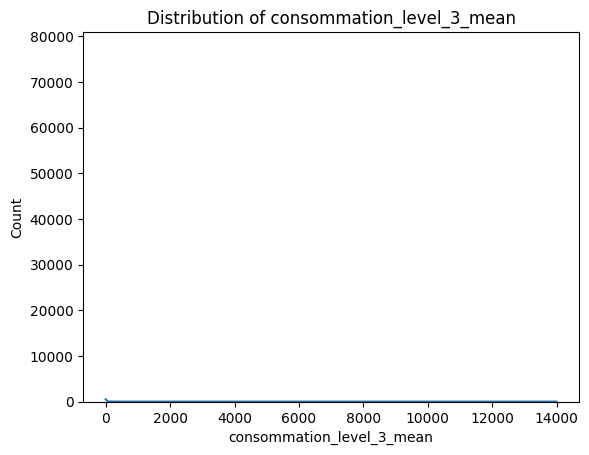

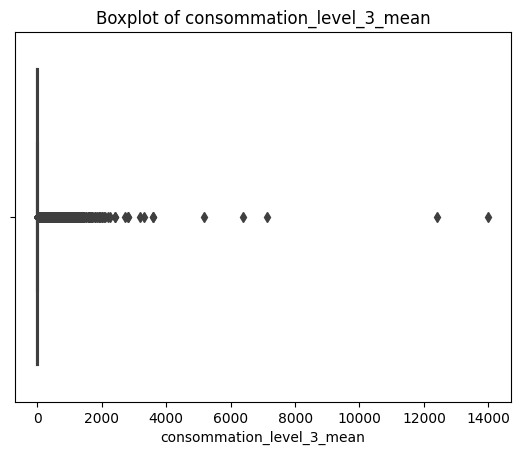

-----------------------------
consommation_level_3_std
count    108394.000000
mean         49.792019
std         139.609508
min           0.000000
25%           0.000000
50%           0.000000
75%          22.682870
max       10657.842526
Name: consommation_level_3_std, dtype: float64


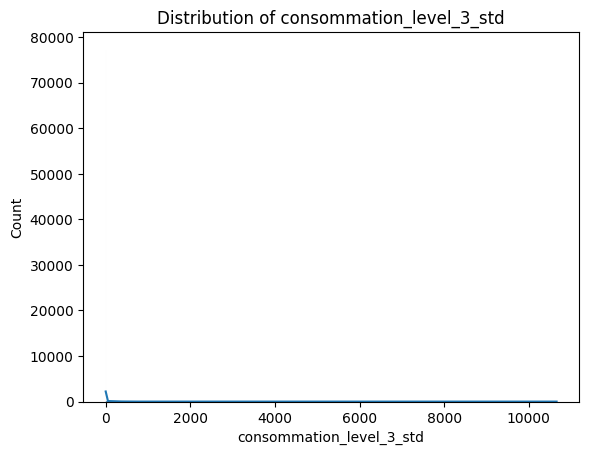

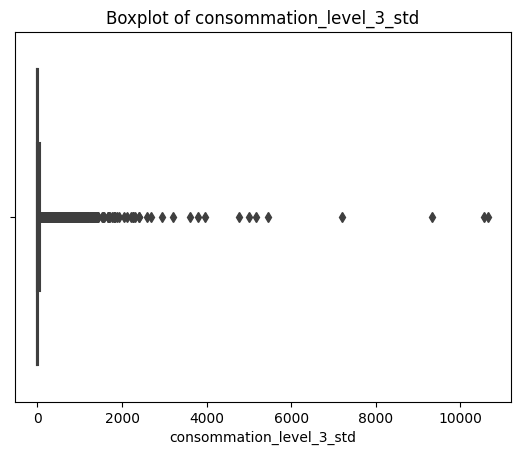

-----------------------------
consommation_level_4_mean
count    108394.000000
mean         71.731349
std         803.804727
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       79179.777778
Name: consommation_level_4_mean, dtype: float64


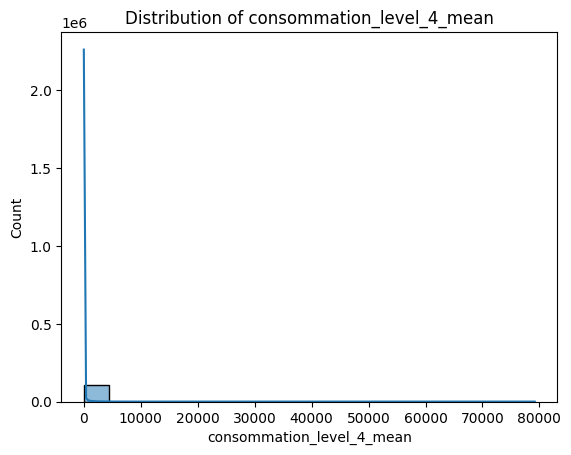

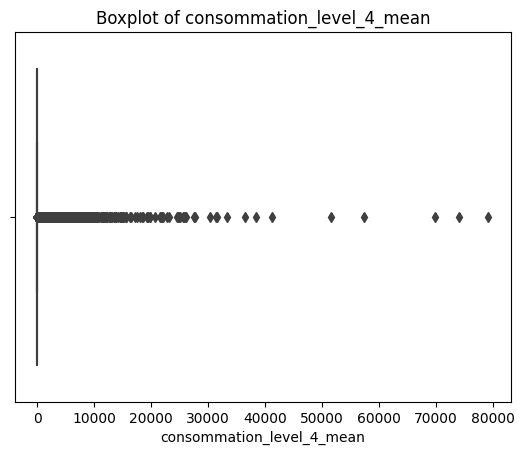

-----------------------------
consommation_level_4_std
count    108394.000000
mean        109.948175
std         897.785399
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      109586.099833
Name: consommation_level_4_std, dtype: float64


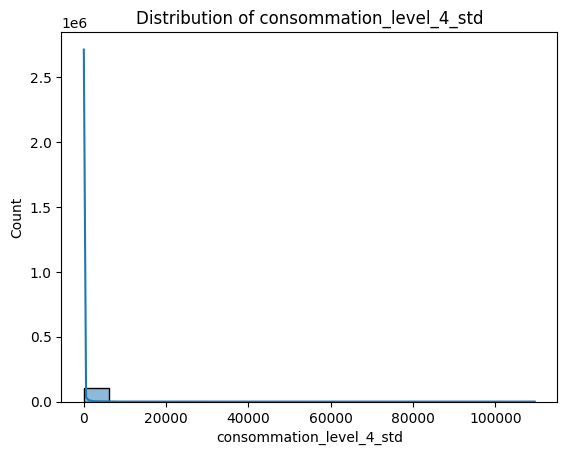

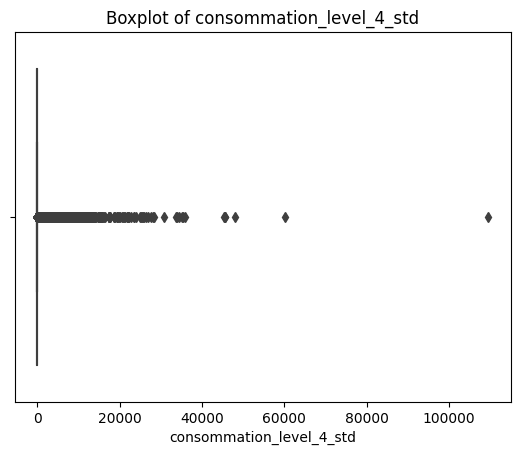

-----------------------------
diff_index_mean
count    108394.000000
mean        622.538231
std        3375.690989
min     -498591.500000
25%         227.757576
50%         389.562030
75%         635.020270
max      596828.687500
Name: diff_index_mean, dtype: float64


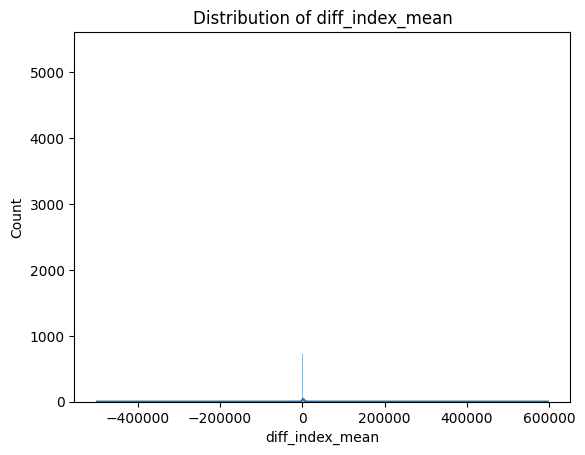

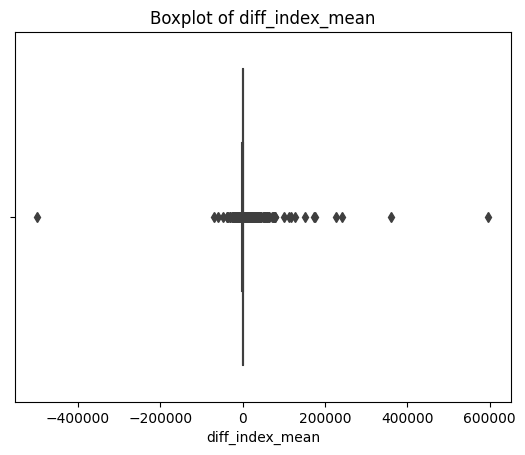

-----------------------------
diff_index_std
count    108394.000000
mean        729.039925
std        3470.427381
min           0.000000
25%         176.801456
50%         317.140073
75%         552.512854
max      707820.251929
Name: diff_index_std, dtype: float64


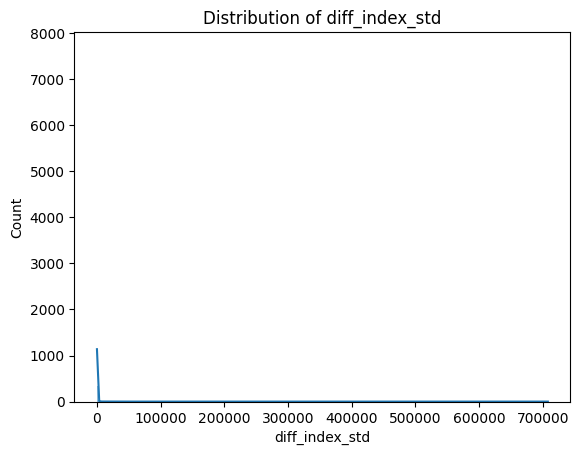

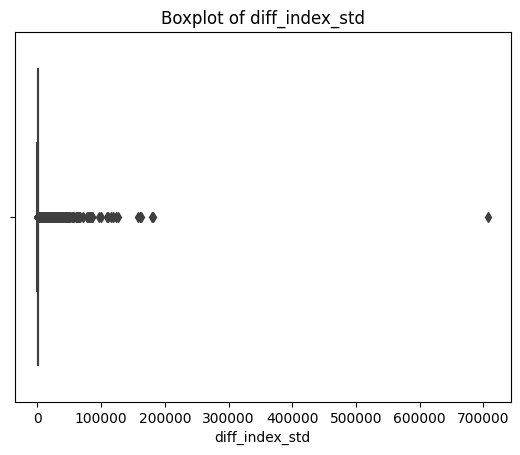

-----------------------------


In [71]:
for col in numeric_cols:    
    # Summary statistics
    print(col)
    print(X_train[col].describe())

    # Visualizations
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    sns.boxplot(x=X_train[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

    print('-----------------------------')

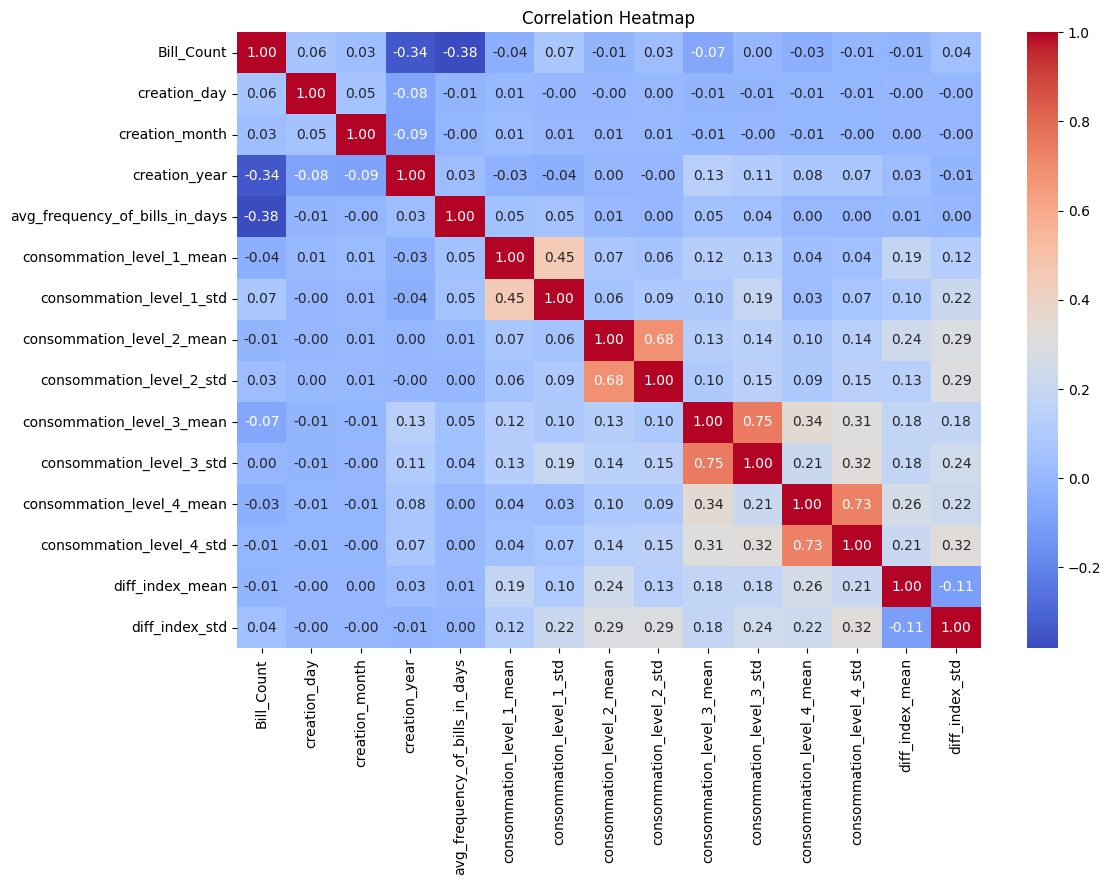

In [72]:
corr_matrix = X_train[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Feature Engineering

#### categorical variables

We are going to do OneHotEncoding for all of our categorical variables

In [73]:
categorical_cols

['disrict',
 'client_catg',
 'region',
 'tarif_type_mode',
 'counter_coefficient_mode',
 'counter_type_mode',
 'reading_remarque_min',
 'reading_remarque_mode',
 'single_bill_client']

In [74]:
cat_cols_fe_all = ['disrict',
 'client_catg',
 'region',
 'tarif_type_mode',
 'counter_coefficient_mode',
 'counter_type_mode',
 'reading_remarque_min',
 'reading_remarque_mode']

In [75]:
ohe = OneHotEncoder(handle_unknown='ignore',drop='first', sparse=False)

In [76]:
X_train_encoded = ohe.fit_transform(X_train[cat_cols_fe_all])
X_train_encoded

,disrict_62,disrict_63,disrict_69,client_catg_12,client_catg_51,region_103,region_104,region_105,region_106,region_107,...,reading_remarque_min_7,reading_remarque_min_8,reading_remarque_min_9,reading_remarque_min_203,reading_remarque_min_413,reading_remarque_mode_7,reading_remarque_mode_8,reading_remarque_mode_9,reading_remarque_mode_203,reading_remarque_mode_413
75532,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
123094,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
114229,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48514,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
130130,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8615,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90010,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86943,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [77]:
X_test_encoded = ohe.transform(X_test[cat_cols_fe_all])
X_test_encoded

,disrict_62,disrict_63,disrict_69,client_catg_12,client_catg_51,region_103,region_104,region_105,region_106,region_107,...,reading_remarque_min_7,reading_remarque_min_8,reading_remarque_min_9,reading_remarque_min_203,reading_remarque_min_413,reading_remarque_mode_7,reading_remarque_mode_8,reading_remarque_mode_9,reading_remarque_mode_203,reading_remarque_mode_413
41228,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
114096,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
90052,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28531,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
78661,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7477,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
116669,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
126843,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
108981,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [78]:
X_train_fe_all = X_train.copy()
X_test_fe_all = X_test.copy()

In [79]:
X_train_fe_all.drop(columns=cat_cols_fe_all, inplace=True)

In [80]:
X_train_fe_all

,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_mean,consommation_level_4_std,diff_index_mean,diff_index_std
75532,22,25,12,2015,58.285714,0,588.409091,371.988435,157.409091,195.177736,238.045455,364.124845,470.272727,828.775987,1454.136364,1514.320916
123094,14,13,11,2010,67.076923,0,478.142857,611.322634,199.642857,420.315560,0.000000,0.000000,0.000000,0.000000,677.785714,967.714530
114229,31,28,10,2008,135.800000,0,413.870968,109.810061,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,413.870968,109.810061
48514,48,29,10,1984,108.851064,0,477.583333,339.124645,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,477.583333,339.124645
130130,65,24,3,1989,79.187500,0,258.000000,155.234802,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,258.000000,155.234802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8615,42,20,11,1997,128.780488,0,999.142857,187.992939,214.857143,255.370660,24.071429,111.108032,0.000000,0.000000,1238.071429,375.001879
90010,67,10,6,1998,74.651515,0,297.611940,260.094619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,295.671642,261.842966
100490,34,12,7,2008,125.909091,0,415.470588,338.327368,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,415.470588,338.327368
86943,27,9,12,2013,70.384615,0,206.888889,203.458999,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.888889,203.458999


In [81]:
# Concatenate along columns
X_train_fe_all = pd.concat([X_train_fe_all, X_train_encoded], axis=1)
X_train_fe_all

,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,...,reading_remarque_min_7,reading_remarque_min_8,reading_remarque_min_9,reading_remarque_min_203,reading_remarque_min_413,reading_remarque_mode_7,reading_remarque_mode_8,reading_remarque_mode_9,reading_remarque_mode_203,reading_remarque_mode_413
75532,22,25,12,2015,58.285714,0,588.409091,371.988435,157.409091,195.177736,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
123094,14,13,11,2010,67.076923,0,478.142857,611.322634,199.642857,420.315560,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
114229,31,28,10,2008,135.800000,0,413.870968,109.810061,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48514,48,29,10,1984,108.851064,0,477.583333,339.124645,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
130130,65,24,3,1989,79.187500,0,258.000000,155.234802,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8615,42,20,11,1997,128.780488,0,999.142857,187.992939,214.857143,255.370660,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90010,67,10,6,1998,74.651515,0,297.611940,260.094619,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100490,34,12,7,2008,125.909091,0,415.470588,338.327368,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86943,27,9,12,2013,70.384615,0,206.888889,203.458999,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [82]:
X_test_fe_all.drop(columns=cat_cols_fe_all, inplace=True)
X_test_fe_all

,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_mean,consommation_level_4_std,diff_index_mean,diff_index_std
41228,26,24,12,2008,148.320000,0,190.615385,271.093943,6.692308,34.124208,0.000000,0.000000,0.000000,0.000000,197.307692,288.338380
114096,30,13,9,2014,58.620690,0,291.000000,169.357813,0.633333,3.468910,0.000000,0.000000,0.000000,0.000000,291.633333,169.041004
90052,55,7,11,1989,92.370370,0,249.981818,374.443166,207.254545,498.324497,101.654545,304.079438,15.200000,73.754196,574.090909,1003.806981
28531,58,10,11,1993,86.877193,0,693.655172,534.473985,110.879310,296.696376,0.000000,0.000000,0.000000,0.000000,804.534483,715.475605
78661,32,29,12,2012,73.548387,0,134.937500,144.914644,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.937500,144.914644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7477,43,16,11,1998,119.238095,0,11.232558,7.450910,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.232558,7.450910
116669,26,28,2,1992,199.520000,0,483.192308,409.988099,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,483.192308,409.988099
126843,31,22,11,2008,127.833333,0,974.193548,211.294016,3073.741935,3075.944700,412.903226,406.400406,2628.354839,2679.213498,7089.193548,1465.477179
108981,43,28,3,2002,118.666667,0,407.511628,131.364519,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.511628,131.364519


In [83]:
X_test_fe_all = pd.concat([X_test_fe_all, X_test_encoded], axis=1)
X_test_fe_all

,Bill_Count,creation_day,creation_month,creation_year,avg_frequency_of_bills_in_days,single_bill_client,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_mean,consommation_level_2_std,...,reading_remarque_min_7,reading_remarque_min_8,reading_remarque_min_9,reading_remarque_min_203,reading_remarque_min_413,reading_remarque_mode_7,reading_remarque_mode_8,reading_remarque_mode_9,reading_remarque_mode_203,reading_remarque_mode_413
41228,26,24,12,2008,148.320000,0,190.615385,271.093943,6.692308,34.124208,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
114096,30,13,9,2014,58.620690,0,291.000000,169.357813,0.633333,3.468910,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
90052,55,7,11,1989,92.370370,0,249.981818,374.443166,207.254545,498.324497,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28531,58,10,11,1993,86.877193,0,693.655172,534.473985,110.879310,296.696376,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
78661,32,29,12,2012,73.548387,0,134.937500,144.914644,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7477,43,16,11,1998,119.238095,0,11.232558,7.450910,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
116669,26,28,2,1992,199.520000,0,483.192308,409.988099,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
126843,31,22,11,2008,127.833333,0,974.193548,211.294016,3073.741935,3075.944700,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
108981,43,28,3,2002,118.666667,0,407.511628,131.364519,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Baseline Model

In [84]:
# Create a baseline classifier with a simple strategy
baseline_clf = DummyClassifier(strategy='most_frequent', random_state=42)

# Fit the model to the training data
baseline_clf.fit(X_train_fe_all, y_train)

# Make predictions
y_pred_bl = baseline_clf.predict(X_test_fe_all)

# Evaluate the baseline model
accuracy_bl = accuracy_score(y_test, y_pred_bl)
roc_auc_bl = roc_auc_score(y_test, y_pred_bl)
recall_bl = recall_score(y_test, y_pred_bl)
f1_bl = f1_score(y_test, y_pred_bl)
print("Baseline Accuracy:", accuracy_bl)
print("Baseline ROC AUC:", roc_auc_bl)
print("Baseline Recall:", recall_bl)
print("Baseline F1-Score:", f1_bl)
print("\nClassification Report:\n", classification_report(y_test, y_pred_bl))


Baseline Accuracy: 0.9441676814642607
Baseline ROC AUC: 0.5
Baseline Recall: 0.0
Baseline F1-Score: 0.0

Classification Report:
               precision    recall  f1-score   support

         0.0       0.94      1.00      0.97     25586
         1.0       0.00      0.00      0.00      1513

    accuracy                           0.94     27099
   macro avg       0.47      0.50      0.49     27099
weighted avg       0.89      0.94      0.92     27099



### Handleing Data Imbalance

We can see from our baseline we have 94 % accuracy but all other metrics are poor. Since the metric we are using is AUC we can see that it is 0.5 which is just as good as random guessing. Before we proceed and train and test other models, we have to take care of this data imbalance. we can do this by SMOTE.

### SMOTE

In [85]:
# Instantiating smote
smote = SMOTE()
# Fitting smote
X_train_fe_all_smote, y_train_smote= smote.fit_resample(X_train_fe_all, y_train)

In [86]:
y_train_smote.value_counts(normalize=True)

target
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

As we can see, we made it go from a imbalanced data class to a balanced data class


### Modeling

In [87]:
logreg = LogisticRegression(
    max_iter=1000,      # Increase iterations if you have many features
    class_weight='balanced',  # Optional if data is imbalanced
    random_state=42
)

In [88]:
#scaler = StandardScaler()

In [89]:
#X_train_scale = scaler.fit_transform(X_train_fe_all_smote)

In [90]:
logreg.fit(X_train_fe_all_smote, y_train_smote)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [91]:
y_pred_lr = logreg.predict(X_test_fe_all)

In [92]:
# Evaluate the baseline model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print("LR Accuracy:", accuracy_lr)
print("LR ROC AUC:", roc_auc_lr)
print("LR Recall:", recall_lr)
print("LR F1-Score:", f1_lr)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

LR Accuracy: 0.6662238458983726
LR ROC AUC: 0.6494348027509468
LR Recall: 0.6305353602115004
LR F1-Score: 0.1741988496302383

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.67      0.79     25586
         1.0       0.10      0.63      0.17      1513

    accuracy                           0.67     27099
   macro avg       0.53      0.65      0.48     27099
weighted avg       0.92      0.67      0.76     27099



In [93]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.97      0.67      0.79     25586
         1.0       0.10      0.63      0.17      1513

    accuracy                           0.67     27099
   macro avg       0.53      0.65      0.48     27099
weighted avg       0.92      0.67      0.76     27099



In [94]:
X_train_encoded

,disrict_62,disrict_63,disrict_69,client_catg_12,client_catg_51,region_103,region_104,region_105,region_106,region_107,...,reading_remarque_min_7,reading_remarque_min_8,reading_remarque_min_9,reading_remarque_min_203,reading_remarque_min_413,reading_remarque_mode_7,reading_remarque_mode_8,reading_remarque_mode_9,reading_remarque_mode_203,reading_remarque_mode_413
75532,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
123094,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
114229,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48514,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
130130,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8615,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90010,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86943,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [95]:
dt = DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=None, random_state=42)

In [96]:
dt.fit(X_train_fe_all_smote, y_train_smote)

DecisionTreeClassifier(random_state=42)

In [97]:
y_pred_dt = dt.predict(X_test_fe_all)

In [98]:
# Evaluate the baseline model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
roc_auc_dt= roc_auc_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_lr)
print("Baseline Accuracy:", accuracy_dt)
print("Baseline ROC AUC:", roc_auc_dt)
print("Baseline Recall:", recall_dt)
print("Baseline F1-Score:", f1_dt)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Baseline Accuracy: 0.8882246577364479
Baseline ROC AUC: 0.5446860552302413
Baseline Recall: 0.1579643093192333
Baseline F1-Score: 0.1741988496302383

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.67      0.79     25586
         1.0       0.10      0.63      0.17      1513

    accuracy                           0.67     27099
   macro avg       0.53      0.65      0.48     27099
weighted avg       0.92      0.67      0.76     27099



In [99]:
# Get feature importance
importance = pd.DataFrame({
    'Feature': X_train_fe_all_smote.columns,
    'Coefficient': logreg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

importance.head(15)


,Feature,Coefficient
0,Bill_Count,0.027410
18,disrict_69,0.015845
21,region_103,0.013811
17,disrict_63,0.011608
45,tarif_type_mode_10,0.010286
38,region_311,0.009605
65,reading_remarque_min_6,0.008614
25,region_107,0.004739
11,consommation_level_3_std,0.003537
72,reading_remarque_mode_8,0.003416


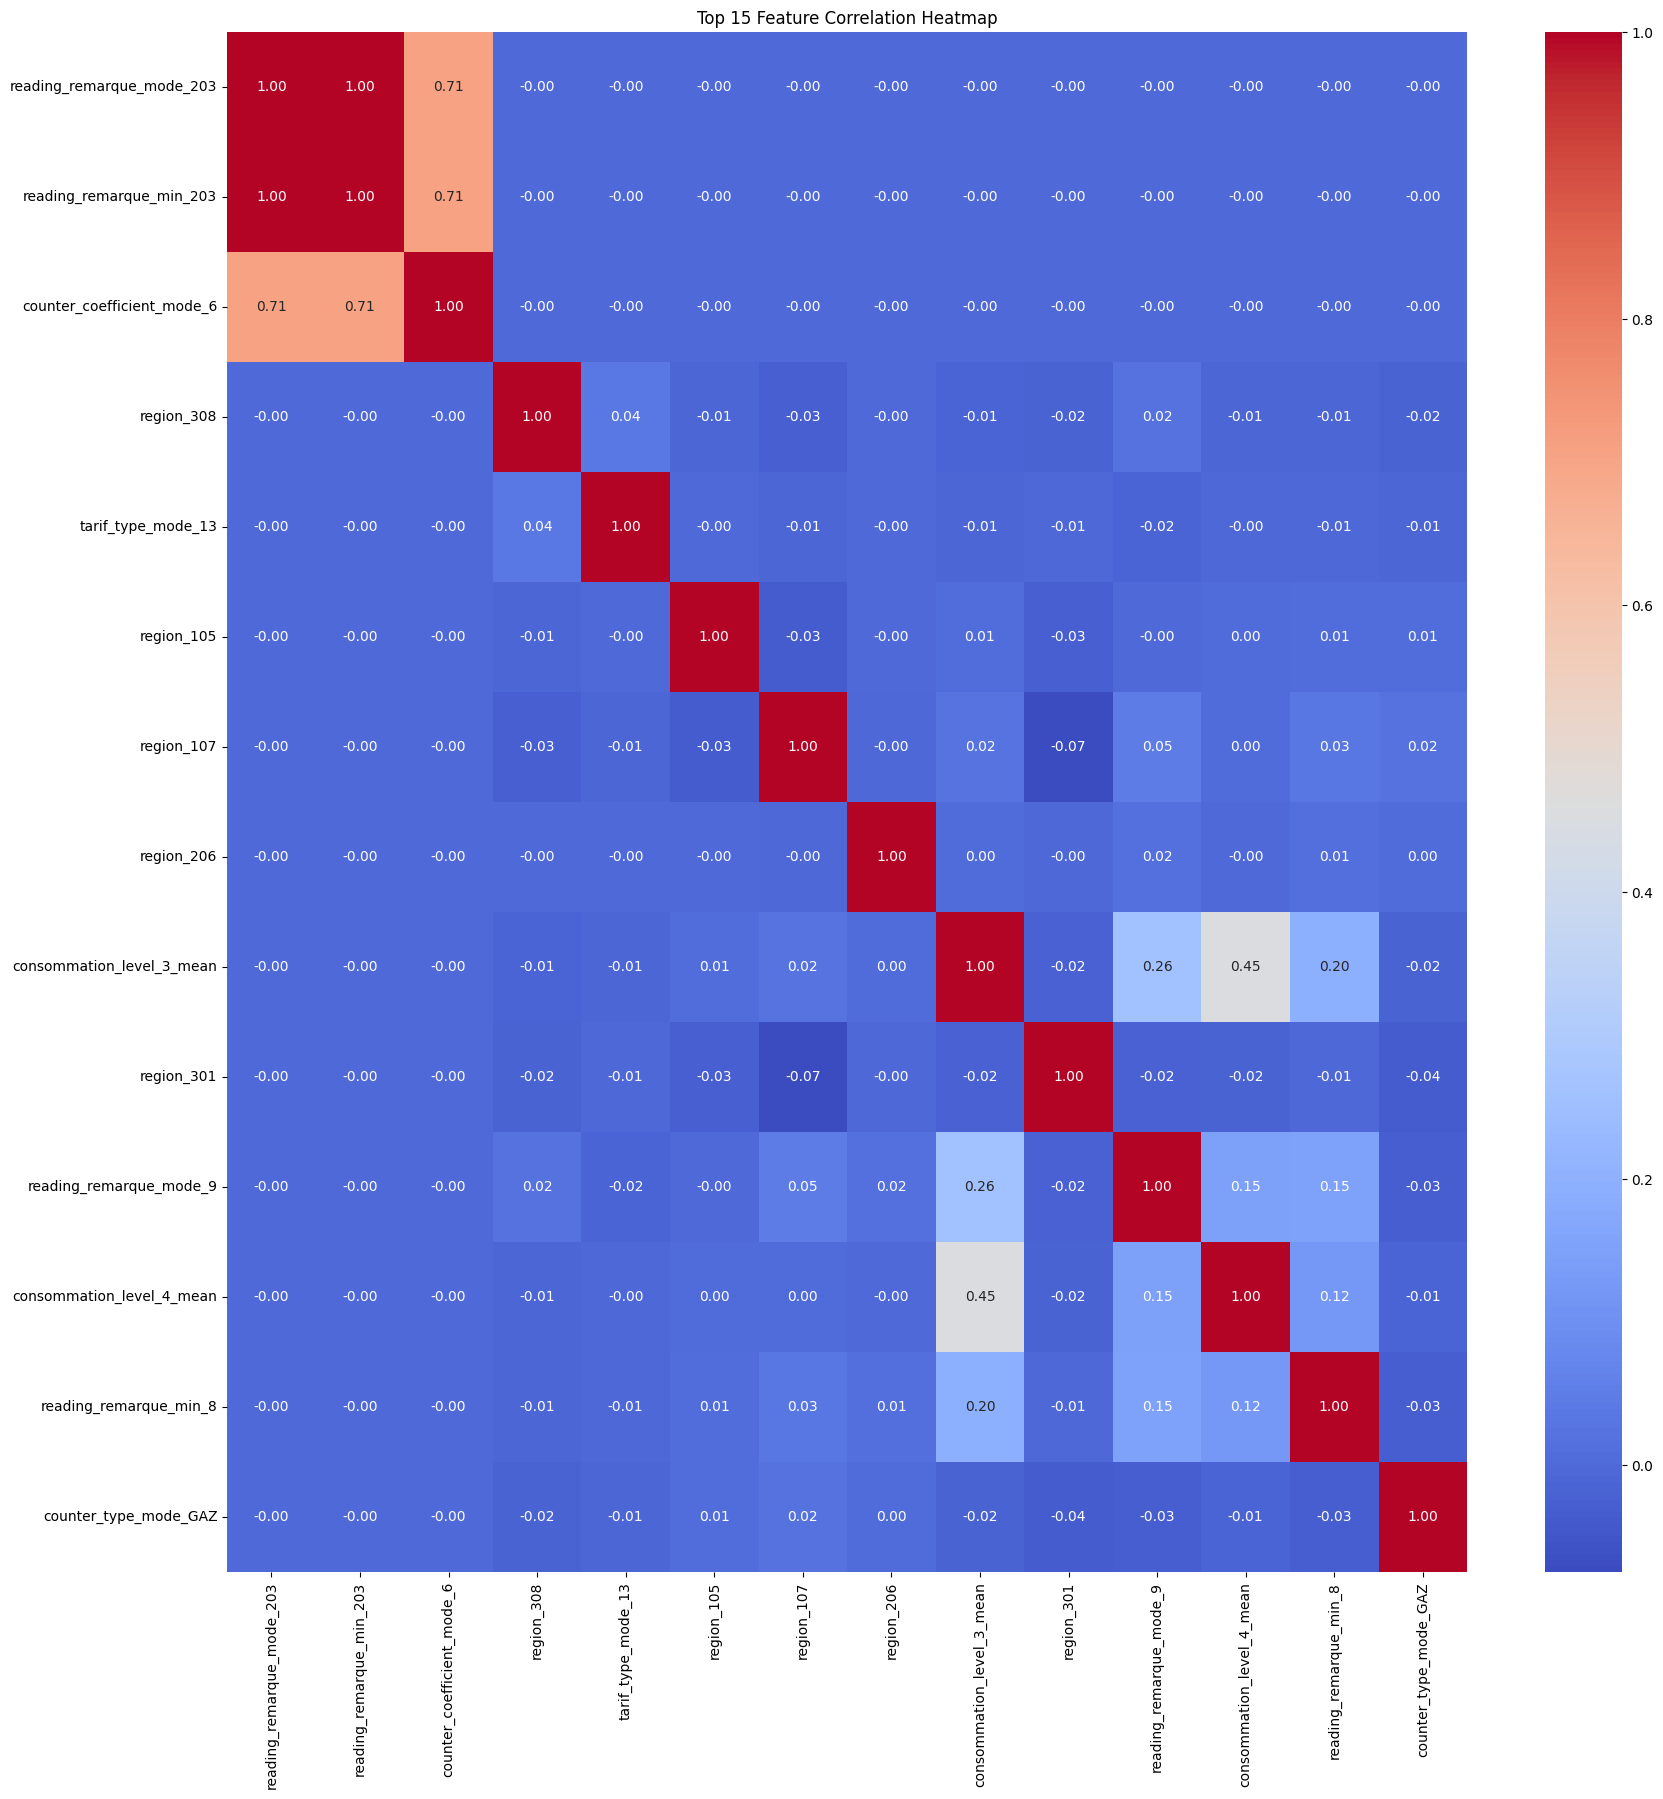

In [100]:
# Assuming `X_train_fe_all_smote` is your feature-engineered dataset (features only)
# Assuming `y_train` contains the target variable

# Add the target column temporarily for correlation calculation
X_train_with_target = X_train_fe_all_smote.copy()
X_train_with_target['target'] = y_train

# Calculate the correlation matrix
correlation_matrix = X_train_with_target.corr()

# Get the top 15 features with the highest absolute correlations with 'target'
top_positive_features = correlation_matrix['target'].abs().sort_values(ascending=False).head(15).index

# Exclude 'target' from the final heatmap since it's not a feature
top_features = top_positive_features.drop('target')

# Create a heatmap with the selected features
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix.loc[top_features, top_features], annot=True, fmt=".2f", cmap="coolwarm")

plt.title('Top 15 Feature Correlation Heatmap')
plt.show()


In [101]:
print(top_features)

Index(['reading_remarque_mode_203', 'reading_remarque_min_203',
       'counter_coefficient_mode_6', 'region_308', 'tarif_type_mode_13',
       'region_105', 'region_107', 'region_206', 'consommation_level_3_mean',
       'region_301', 'reading_remarque_mode_9', 'consommation_level_4_mean',
       'reading_remarque_min_8', 'counter_type_mode_GAZ'],
      dtype='object')


In [102]:
# Filter the dataset to include only the top features
X_train_filtered = X_train_fe_all_smote[top_features]
X_train_filtered

,reading_remarque_mode_203,reading_remarque_min_203,counter_coefficient_mode_6,region_308,tarif_type_mode_13,region_105,region_107,region_206,consommation_level_3_mean,region_301,reading_remarque_mode_9,consommation_level_4_mean,reading_remarque_min_8,counter_type_mode_GAZ
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,238.045455,0.0,1.000000,470.272727,1.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.000000,0.000000,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.000000,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.203306
204678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,57.536737,0.0,0.000000,14.414263,0.0,0.140005
204679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.972964,0.0,0.000000,7.580026,0.0,0.202116
204680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.000655,0.0,0.892966,4.475344,0.0,0.000000


In [103]:
X_test_filtered = X_test_fe_all[top_features]
X_test_filtered

,reading_remarque_mode_203,reading_remarque_min_203,counter_coefficient_mode_6,region_308,tarif_type_mode_13,region_105,region_107,region_206,consommation_level_3_mean,region_301,reading_remarque_mode_9,consommation_level_4_mean,reading_remarque_min_8,counter_type_mode_GAZ
41228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.000000,0.0,0.0
114096,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.000000,0.0,0.0
90052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101.654545,0.0,0.0,15.200000,0.0,0.0
28531,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
78661,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7477,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
116669,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
126843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,412.903226,0.0,1.0,2628.354839,0.0,0.0
108981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0


In [104]:
dt.fit(X_train_filtered, y_train_smote)

DecisionTreeClassifier(random_state=42)

In [105]:
y_pred_dt = dt.predict(X_test_filtered)

In [106]:
# Evaluate the baseline model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
roc_auc_dt= roc_auc_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_lr)
print("Baseline Accuracy:", accuracy_dt)
print("Baseline ROC AUC:", roc_auc_dt)
print("Baseline Recall:", recall_dt)
print("Baseline F1-Score:", f1_dt)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Baseline Accuracy: 0.8749031329569357
Baseline ROC AUC: 0.5537996371011927
Baseline Recall: 0.19233311302048908
Baseline F1-Score: 0.1741988496302383

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.67      0.79     25586
         1.0       0.10      0.63      0.17      1513

    accuracy                           0.67     27099
   macro avg       0.53      0.65      0.48     27099
weighted avg       0.92      0.67      0.76     27099



In [107]:
dt2 = DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=None, random_state=42)

In [108]:
dt2.fit(X_train_filtered, y_train_smote)

DecisionTreeClassifier(random_state=42)

In [109]:
y_pred_dt = dt2.predict(X_test_filtered)

In [110]:
# Evaluate the baseline model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
roc_auc_dt= roc_auc_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_lr)
print("Baseline Accuracy:", accuracy_dt)
print("Baseline ROC AUC:", roc_auc_dt)
print("Baseline Recall:", recall_dt)
print("Baseline F1-Score:", f1_dt)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Baseline Accuracy: 0.8749031329569357
Baseline ROC AUC: 0.5537996371011927
Baseline Recall: 0.19233311302048908
Baseline F1-Score: 0.1741988496302383

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.67      0.79     25586
         1.0       0.10      0.63      0.17      1513

    accuracy                           0.67     27099
   macro avg       0.53      0.65      0.48     27099
weighted avg       0.92      0.67      0.76     27099



In [111]:
# Get the top 30 features with the highest absolute correlations with 'target'
top_30_features = correlation_matrix['target'].abs().sort_values(ascending=False).head(30).index

# Exclude 'target' from the final feature list
top_30_features = top_30_features.drop('target')

print("Top 30 features based on correlation with target:\n", top_30_features)


Top 30 features based on correlation with target:
 Index(['reading_remarque_mode_203', 'reading_remarque_min_203',
       'counter_coefficient_mode_6', 'region_308', 'tarif_type_mode_13',
       'region_105', 'region_107', 'region_206', 'consommation_level_3_mean',
       'region_301', 'reading_remarque_mode_9', 'consommation_level_4_mean',
       'reading_remarque_min_8', 'counter_type_mode_GAZ', 'tarif_type_mode_29',
       'region_106', 'tarif_type_mode_45', 'single_bill_client',
       'tarif_type_mode_14', 'region_372', 'Bill_Count', 'region_303',
       'disrict_62', 'reading_remarque_mode_7', 'tarif_type_mode_40',
       'disrict_69', 'region_311', 'consommation_level_1_std', 'region_371'],
      dtype='object')


In [112]:
# Filter the training dataset
X_train_top_30 = X_train_fe_all_smote[top_30_features]

# (Optional) Filter the test dataset
X_test_top_30 = X_test_fe_all[top_30_features]

# Verify the new datasets
print("Shape of X_train_top_30:", X_train_top_30.shape)
print("Shape of X_test_top_30:", X_test_top_30.shape)


Shape of X_train_top_30: (204682, 29)
Shape of X_test_top_30: (27099, 29)


In [113]:
# Initialize the Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)

# Train the model on the filtered training dataset
dt_clf.fit(X_train_top_30, y_train_smote)


DecisionTreeClassifier(random_state=42)

In [114]:
# Predict class labels on the test dataset
y_pred = dt_clf.predict(X_test_top_30)




In [115]:
# Calculate key metrics
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Print the metrics
print("Decision Tree Metrics:")
print("Accuracy:", accuracy)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC AUC:", roc_auc)


Decision Tree Metrics:
Accuracy: 0.8671537695117901
Recall: 0.16655651024454726
F1-Score: 0.12280701754385964
ROC AUC: 0.5375696644867698


In [117]:
categorical_cols = ['disrict_62', 'disrict_63',
       'disrict_69', 'client_catg_12', 'client_catg_51', 'region_103',
       'region_104', 'region_105', 'region_106', 'region_107', 'region_199',
       'region_206', 'region_301', 'region_302', 'region_303', 'region_304',
       'region_305', 'region_306', 'region_307', 'region_308', 'region_309',
       'region_310', 'region_311', 'region_312', 'region_313', 'region_371',
       'region_372', 'region_379', 'region_399', 'tarif_type_mode_10',
       'tarif_type_mode_11', 'tarif_type_mode_12', 'tarif_type_mode_13',
       'tarif_type_mode_14', 'tarif_type_mode_15', 'tarif_type_mode_21',
       'tarif_type_mode_24', 'tarif_type_mode_29', 'tarif_type_mode_30',
       'tarif_type_mode_40', 'tarif_type_mode_45',
       'counter_coefficient_mode_2', 'counter_coefficient_mode_3',
       'counter_coefficient_mode_6', 'counter_coefficient_mode_20',
       'counter_coefficient_mode_30', 'counter_coefficient_mode_40',
       'counter_coefficient_mode_50', 'counter_type_mode_GAZ',
       'reading_remarque_min_6', 'reading_remarque_min_7',
       'reading_remarque_min_8', 'reading_remarque_min_9',
       'reading_remarque_min_203', 'reading_remarque_min_413',
       'reading_remarque_mode_7', 'reading_remarque_mode_8',
       'reading_remarque_mode_9', 'reading_remarque_mode_203',
       'reading_remarque_mode_413']

In [118]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Define the transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),  # Apply scaler to numerical columns
        ('cat', 'passthrough', categorical_cols)   # Leave categorical columns as is
    ]
)

# Transform the training and test datasets
X_train_scaled = preprocessor.fit_transform(X_train_fe_all_smote)
X_test_scaled = preprocessor.transform(X_test_fe_all)


In [119]:
X_train_fe_all_smote.columns

Index(['Bill_Count', 'creation_day', 'creation_month', 'creation_year',
       'avg_frequency_of_bills_in_days', 'single_bill_client',
       'consommation_level_1_mean', 'consommation_level_1_std',
       'consommation_level_2_mean', 'consommation_level_2_std',
       'consommation_level_3_mean', 'consommation_level_3_std',
       'consommation_level_4_mean', 'consommation_level_4_std',
       'diff_index_mean', 'diff_index_std', 'disrict_62', 'disrict_63',
       'disrict_69', 'client_catg_12', 'client_catg_51', 'region_103',
       'region_104', 'region_105', 'region_106', 'region_107', 'region_199',
       'region_206', 'region_301', 'region_302', 'region_303', 'region_304',
       'region_305', 'region_306', 'region_307', 'region_308', 'region_309',
       'region_310', 'region_311', 'region_312', 'region_313', 'region_371',
       'region_372', 'region_379', 'region_399', 'tarif_type_mode_10',
       'tarif_type_mode_11', 'tarif_type_mode_12', 'tarif_type_mode_13',
       'tarif_

In [120]:
logreg.fit(X_train_scaled, y_train_smote)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [121]:
y_pred_lr = logreg.predict(X_test_scaled)

In [122]:
# Evaluate the baseline model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print("LR Accuracy:", accuracy_lr)
print("LR ROC AUC:", roc_auc_lr)
print("LR Recall:", recall_lr)
print("LR F1-Score:", f1_lr)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

LR Accuracy: 0.6753385733790915
LR ROC AUC: 0.6726063736214797
LR Recall: 0.6695307336417713
LR F1-Score: 0.18717664449371768

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.68      0.80     25586
         1.0       0.11      0.67      0.19      1513

    accuracy                           0.68     27099
   macro avg       0.54      0.67      0.49     27099
weighted avg       0.92      0.68      0.76     27099

